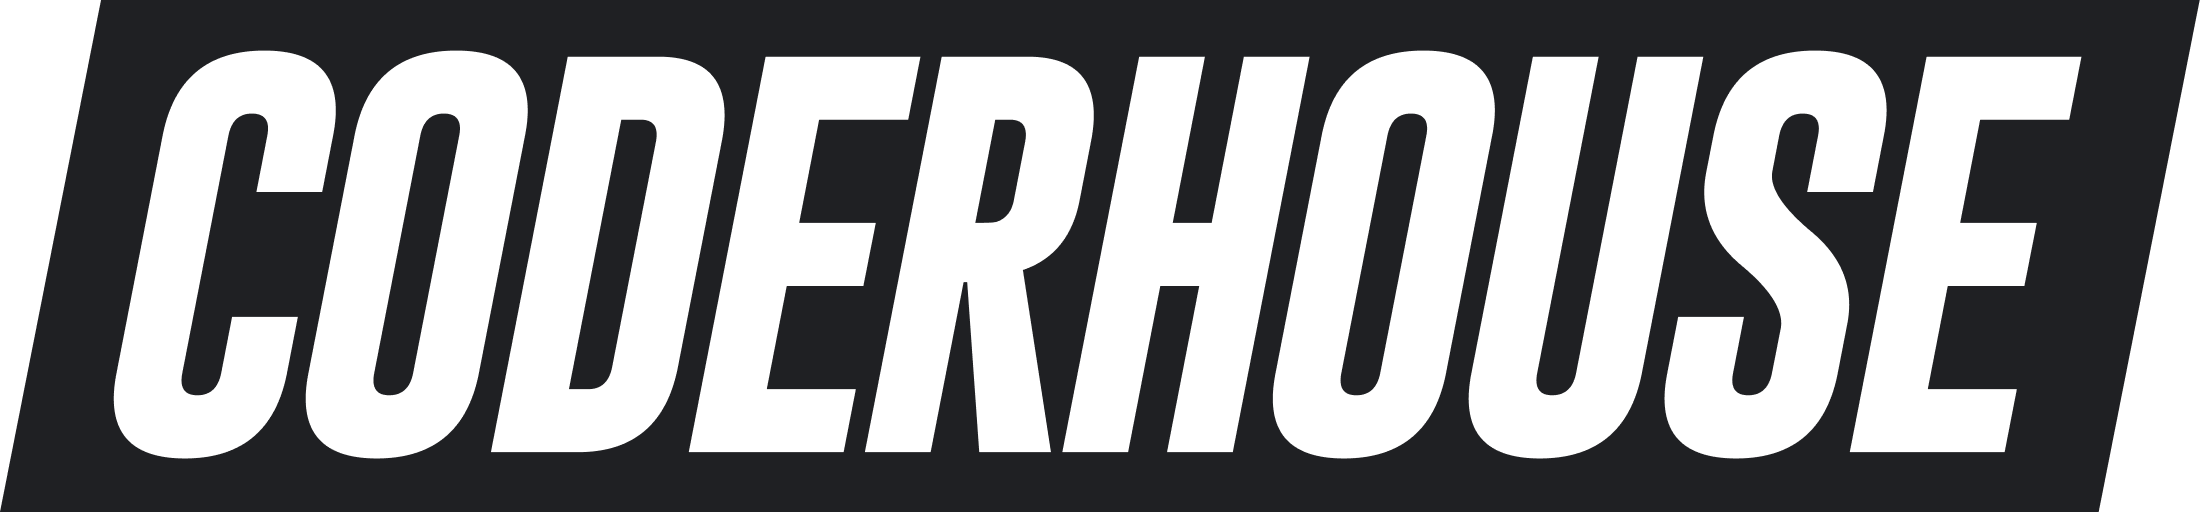

**Alumna:** Palermo Rita Veronica

**Entrega Final**

**Comisiòn Nº: 90480**

***Profesor: Ezequiel Juan Bassano***

**Tutor: Carlos Davoli**

 # Temario de análisis de Datos: "RESEÑAS DE MEDICAMENTOS- DRUG REVIEWS"


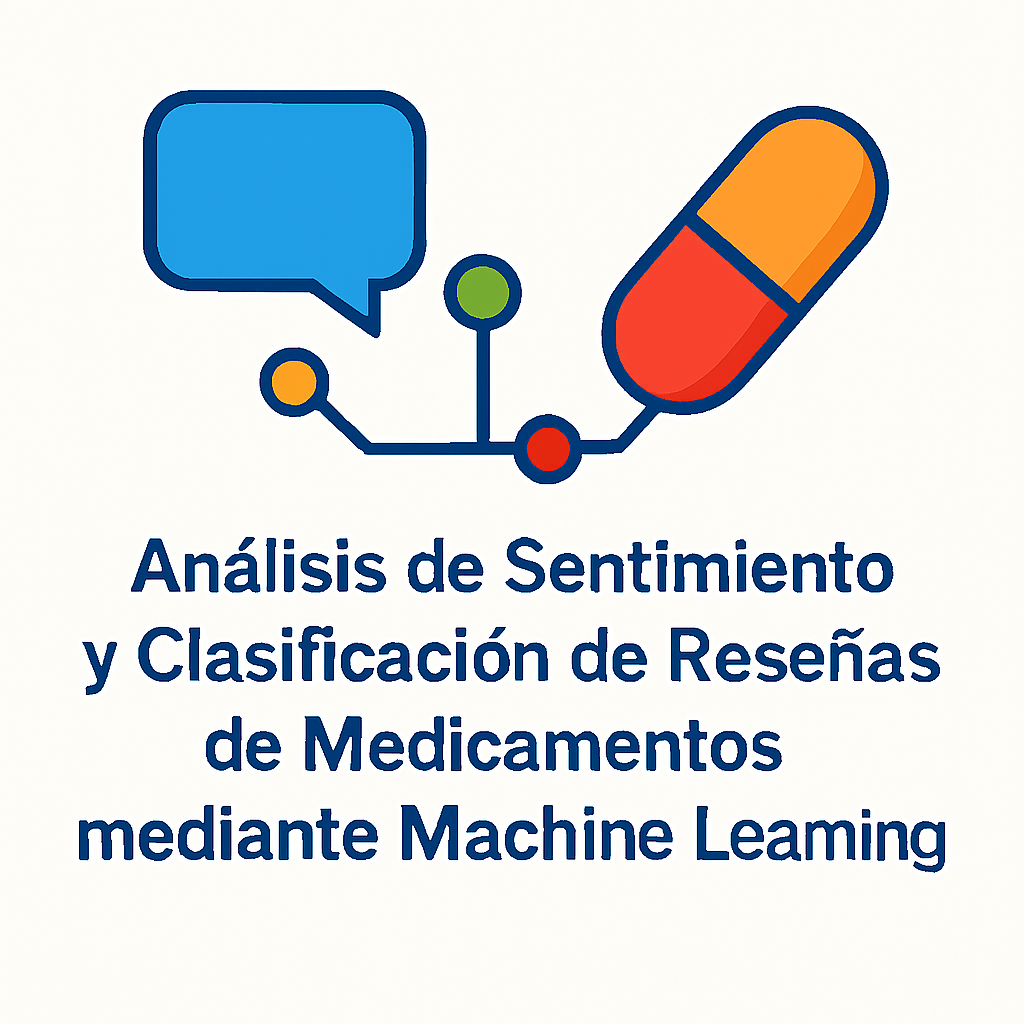

**INDICE:**



**1- INTRODUCCIÓN.**

**2- JUSTIFICACIÓN Y DESCRIPCIÓN DEL PROBLEMA.**

**3- OBJETIVO GENERAL.**

**4- ORIGEN DE LOS DATOS.**

**5- DATASET Y DEFINICIÓN DE VARIABLES.**

**6- LIBRERÍAS A UTILIZAR.**

**7- PREPARACIÓN DE LOS DATOS.**

**8- ESTADÍSTICA DESCRIPTIVA.**

**9- DATA WRANGLING: CURACIÓN Y PREPARACIÓN DEL DATASET.**

**10- USO DE SPACY Y SCISPACY.**

**11- N-GRAMAS Y ANALÍSIS DE SENTIMIENTO.**

**12- ETIQUETADO GRAMATICAL (POS) Y DEPENDENCIAS.**

**13- DESGLOSE METODOLÓGICO DE PREPROCESAMIENTO DE TEXTO.**

**14- ANÁLISIS LINGUÍSTICO AVANZADO.**

**15- WORDCLOUND.**

**16- ETIQUETADO DÉBIL DE SENTIMIENTO (VADER).**

**17- BASELINE CLASICO: TF-IDF + REGRESIÓN LOGÍSTICA.**

**18- DEEP LEARNING (REDES NEURONALES).**

**19- CONCLUSIONES.**

**20- PREDICCIONES FUTURAS.**


 # 1- INTRODUCCIÓN:

En la era digital, la experiencia del paciente ha dejado de limitarse al consultorio médico para trasladarse a las plataformas digitales. El análisis de reseñas de medicamentos (Drug Reviews) representa una oportunidad invaluable para entender cómo los fármacos afectan la vida cotidiana de las personas más allá de los ensayos clínicos controlados. Este trabajo se centra en el estudio de miles de testimonios reales, buscando identificar patrones en la efectividad de los tratamientos y la presencia de efectos secundarios. A través de técnicas de Ciencia de Datos, este proyecto pretende transformar opiniones subjetivas en información objetiva que pueda ayudar a mejorar la toma de decisiones en el ámbito de la salud.




 # 2- JUSTIFICACIÓN Y DESCRIPCIÓN DEL PROBLEMA:

El **problema** central radica en la gestión del volumen masivo de datos no estructurados y la asimetría de información resultante. Actualmente, las instituciones de salud y empresas farmacéuticas se enfrentan a una brecha crítica: la incapacidad de procesar manualmente miles de reportes diarios de pacientes para extraer insights de valor, lo cual resulta técnica y económicamente ineficiente.

Este proyecto se justifica en la necesidad de automatizar la farmacovigilancia mediante la "voz del paciente" (Patient's Voice). El desarrollo de un sistema inteligente permitirá:


* Clasificar de forma automatizada la polaridad de las experiencias (satisfacción vs. insatisfacción).

* Detectar patrones emergentes de efectos secundarios o fallas en la eficacia sin intervención humana constante.

* Optimizar la seguridad farmacológica y la adherencia a los tratamientos basada en datos masivos y reales.



 # 3- OBJETIVO GENERAL:

 Analizar el dataset de Drug Reviews mediante técnicas de Procesamiento de Lenguaje Natural (NLP) y Machine Learning para identificar tendencias de satisfacción del paciente y construir un modelo predictivo capaz de clasificar la valoración de un medicamento a partir del texto de la reseña.



# 4- ORIGEN DE LOS DATOS:

Los datos utilizados en este proyecto provienen del UCI Machine Learning Repository, específicamente del 'Drug Review Dataset (Drugs.com), la cual es una de las fuentes de información farmacéutica más grandes en la web.

Este dataset fue recolectado originalmente de la plataforma kaggle.

# 5- DATASET Y DEFINICIÓN DE LAS VARIABLES:

Este conjunto de datos contiene más de 10.000 reseñas Y 12 columnas.

Las cuales se seleccionaron las más importantes para este análisis:

* **DrugName** : Nombre del medicamento analizado.

* **Condition**: Condición médica o enfermedad para la cual se receta el fármaco.

* **Review**: Comentario textual del paciente sobre su experiencia (Variable principal para NLP).

* **Rating**: Calificación numérica del 1 al 10 otorgada por el usuario.

* **Date**: Fecha en la que se publicó la reseña.

# 6- LIBRERÍAS A UTILIZAR:

* Manipulación de datos: Pandas y NumPy.

* Visualización: Matplotlib y Seaborn.

* NLP (Procesamiento de Lenguaje Natural): NLTK, spaCy (y su variante biomédica scispaCy para mayor precisión en términos médicos) y Re (Expresiones regulares).

* Machine Learning / Deep Learning: para vectorización y modelos clásicos y Keras/TensorFlow (para redes neuronales).



# 7- PREPARACIÓN DE LOS DATOS:

**7."A"- IMPORTACIÓN DE LAS LIBRERIAS A UTILIZAR.**

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**7."B"- IMPORTACÓN DE LIBRERÍA PARA LA DETECCIÓN DE DATOS AUSENTES.**

In [59]:
import missingno as msno

**7."C"- IMPORTACIÓN DE LIBRERIAS PARA IMPUTACIÓN (PARA PODER DEMOSTRAR BUENAS PRÁCTICAS).**

In [60]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import plotly.express as px
import pandas as pd
from scipy.stats import kurtosis
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kurtosis
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

**7."D"- IMPORTACIÓN DE LIBRERIAS PARA LIMPIEZA DE TEXTO:**

In [61]:
import re  # Para expresiones regulares (quitar signos, números, etc.)
import string  # Para manejar signos de puntuación
import nltk  # La librería principal de lenguaje natural
from nltk.corpus import stopwords  # Para quitar palabras "vacías" (the, a, is, etc.)
from nltk.stem import WordNetLemmatizer # Para llevar las palabras a su raíz (opcional pero recomendado)
from nltk.tokenize import word_tokenize
import spacy
from sklearn.feature_extraction.text import CountVectorizer # Import added
from textblob import TextBlob # Import added

!pip install scispacy
import scispacy


# Estas descargas son obligatorias en Google Colab para que NLTK funcione
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

print("✅ Librerías de limpieza de texto cargadas correctamente")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ Librerías de limpieza de texto cargadas correctamente


[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


**7."E"- CARGA DEL DATASET A ANALIZAR Y VISUALIZO LAS 5 PRIMERAS FILAS.**

In [62]:
# Montamos Google Drive
#drive.mount('/content/drive')

from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [63]:
import pandas as pd

# Configura pandas para mostrar todo el contenido de cada celda (sin truncar)
pd.set_option('display.max_colwidth', None)

# Para volver para atrás
# pd.reset_option('display.max_colwidth')

df = pd.read_csv('/content/drive/MyDrive/DATA SET III MEDICAMENTOS.csv', encoding='latin-1', sep=';')

In [64]:
#Visualizo las primeras 5 filas

display(df.head())

,Nombre Droga,Condicion,Reseña,Calificación,Fecha,util count,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil""",9,20-may-12,27,NaN,NaN,NaN,NaN,NaN,NaN
1,Guanfacine,ADHD,"""My son is halfway through his fourth week of Intuniv. We became concerned when he began this last week, when he started taking the highest dose he will be on. For two days, he could hardly get out of bed, was very cranky, and slept for nearly 8 hours on a drive home from school vacation (very unusual for him.) I called his doctor on Monday morning and she said to stick it out a few days. See how he did at school, and with getting up in the morning. The last two days have been problem free. He is MUCH more agreeable than ever. He is less emotional (a good thing), less cranky. He is remembering all the things he should. Overall his behavior is better.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Lybrel,Birth Control,"""I used to take another oral contraceptive, which had 21 pill cycle, and was very happy- very light periods, max 5 days, no other side effects. But it contained hormone gestodene, which is not available in US, so I switched to Lybrel, because the ingredients are similar. When my other pills ended, I started Lybrel immediately, on my first day of period, as the instructions said. And the period lasted for two weeks. When taking the second pack- same two weeks. And now, with third pack things got even worse- my third period lasted for two weeks and now it&#039",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ortho Evra,Birth Control,"""This is my first time using any form of birth control. I&#039",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around. I feel healthier, I&#039",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


 # 8- ESTADÍSTICA DESCRIPTIVA

**8- "A"- Dimensión del Dataset:**

In [65]:
print(df.shape)

(10110, 12)


**Explicación del Resultado:** Tiene 10110 filas y 12 Columnas

**8- "B"- Visión general del Dataset y controlo Valores Nulos**

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10110 entries, 0 to 10109
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Nombre Droga  10107 non-null  object 
 1   Condicion     10047 non-null  object 
 2   Reseña        10079 non-null  object 
 3   Calificación  3846 non-null   object 
 4   Fecha         3836 non-null   object 
 5   util count    3832 non-null   object 
 6   Unnamed: 6    18 non-null     object 
 7   Unnamed: 7    7 non-null      object 
 8   Unnamed: 8    4 non-null      object 
 9   Unnamed: 9    3 non-null      object 
 10  Unnamed: 10   2 non-null      object 
 11  Unnamed: 11   1 non-null      float64
dtypes: float64(1), object(11)
memory usage: 947.9+ KB


**Explicación del Resultado:**

El dataset está "sucio" y desalineado.

Las columnas como calificación, fecha y util count tienen muchisimos valores nulos, solo hay datos en unos 3.800 registros. Significa que ha perdido casi el 60% de los datos en estas columnas.

Las columnas Nombre droga, condicion y reseña, están casi completas, tienen más de 10.000 registros, lo cual es bueno, ya que son las que voy a utilizar para mi analisis.

Como tipos de datos incorrectos (Dtypes): La columna Calificación y util count aparecen como object (texto). Deberían ser float o int para poder hacer promedios o gráficas.

La Fecha también es object y debería ser de tipo datetime.



**8- "C" Describir el Dataset:**

In [67]:
df.describe()

,Unnamed: 11
count,1.0
mean,8.0
std,NaN
min,8.0
25%,8.0
50%,8.0
75%,8.0
max,8.0


**Explicación del resultado:**

Al ejecutar el primer análisis estadístico descriptivo, se observa que el sistema solo reconoce una variable numérica denominada 'Unnamed: 11', la cual carece de valor analítico al contar con un único registro. Las variables críticas, como la 'Calificación', no aparecen en este resumen debido a que están categorizadas incorrectamente como tipo objeto (texto). Este resultado evidencia la necesidad crítica de realizar una transformación de datos y una limpieza de valores nulos para poder obtener métricas reales como el promedio de satisfacción de los usuarios.

**8- "D" Controlo si posse filas repetidas:**

In [68]:
df.duplicated().value_counts()

,count
False,10105
True,5


**Explicación del Resultado:**

False (10,105): Son las filas únicas. La gran mayoría de los datos son registros originales.

True (5): Solo hay 5 filas que son copias exactas de otras ya existentes en el dataset.

**8- "E" Controlo si hay valores Faltantes:**

In [69]:
df.isnull().sum()/len(df)*100

,0
Nombre Droga,0.029674
Condicion,0.623145
Reseña,0.306627
Calificación,61.958457
Fecha,62.057369
util count,62.096934
Unnamed: 6,99.821958
Unnamed: 7,99.930762
Unnamed: 8,99.960435
Unnamed: 9,99.970326


**Explicación del resultado:**

Columnas casi perfecta (0% - 1% de faltantes): Nombre Droga, Condicion y Reseña. Significa que la información principal está ahí en casi todas las filas.

Columnas con pérdida crítica (aprox. 62% de faltantes): Calificación, Fecha y util count. Aquí es donde está el problema real. El hecho de que a más del 60% de tus datos les falte la calificación confirma que hubo un error al cargar el dataset, puede haber sido por un desplazamiento de comas.

Columnas basura (99.8% - 99.9% de faltantes): Las columnas Unnamed. Estas son columnas "fantasma" que se crearon por error y no aportan ninguna información.

# 9- DATA WRANGLING: "CURACIÓN Y PREPARACIÓN DEL DATASET"

Una vez diagnosticado el estado inicial del dataset, se procedió a una limpieza profunda orientada a garantizar la integridad estadística del análisis. Este paso es fundamental ya que los modelos de análisis de datos requieren información estructurada y completa. Al seleccionar únicamente las variables críticas (Nombre del Medicamento, Condición, Reseña y Calificación), eliminamos el 'ruido' de las columnas residuales y nos aseguramos de que cada registro cuente con información suficiente para ser procesado. La conversión de tipos de datos de texto a formato numérico es lo que finalmente habilita la capacidad de realizar cálculos de tendencia central y dispersión sobre las valoraciones de los pacientes.


Este proceso se realiza para:

- Focalizar el análisis: Eliminando columnas irrelevantes que consumen memoria y no aportan valor al estudio de los medicamentos.

- Asegurar la calidad: Eliminando filas con valores faltantes que sesgarían los promedios de calificación.

- Habilitar el cálculo matemático: Transformando la columna 'Calificación' de texto a número para poder obtener métricas como el promedio de satisfacción por enfermedad.

In [70]:
# 1. Seleccionamos ÚNICAMENTE las columnas que me interesan

# He incluido 'Condicion' porque me servirá para agrupar.
columnas_elegidas = ['Nombre Droga', 'Condicion', 'Reseña', 'Calificación']
df_final = df[columnas_elegidas].copy()

# 2. Elimino filas donde falte información en cualquiera de esas columnas
df_final = df_final.dropna()

# 3. Elimino los 5 duplicados
df_final = df_final.drop_duplicates()

# 4. Convierto la Calificación a número (muy importante para las gráficas)
df_final['Calificación'] = pd.to_numeric(df_final['Calificación'], errors='coerce')

# 5. Borramos si quedó algún nulo después de la conversión
df_final = df_final.dropna(subset=['Calificación'])

# --- RESULTADO FINAL ---
print("Columnas actuales:", df_final.columns.tolist())
print(f"Total de registros listos para analizar: {df_final.shape[0]}")
df_final.head()

Columnas actuales: ['Nombre Droga', 'Condicion', 'Reseña', 'Calificación']
Total de registros listos para analizar: 3788


,Nombre Droga,Condicion,Reseña,Calificación
0,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil""",9.0
22,Etanercept,Rheumatoid Arthritis,"""I live in Western Australia and disturbed by some comments on here. The cost of Embrel is cost of an ordinary prescription $36 for me the government pays the remainder of the cost to the chemist. I also go to the the medical centre every Saturday morning a Dr looks over my prescription and then he advises the nurse to administer the injection also no cost to myself and this is part of nurses duties. I am unsure of the country where people who have made comments referring to cost and that nobody is there to administer the injection for them. I am very lucky to live in Australia as we have the best health system worldwide and everybody is given the opportunity to receive proper medical help whether you are rich or poor there is no discrimination.""",10.0
24,Azithromycin,Chlamydia Infection,"""Was prescribed one dose over the course of one day, took 4 pills of 250mg after a light lunch, and had nausea and mild stomach pains/upset. Lying down did not alleviate the discomfort and threw up 3 hours later. Called up my doctor to check if I needed to take another dose but he said my body would have absorbed the pills by then. Still experiencing mild stomach pains but nausea is mostly gone now.""",7.0
25,Daytrana,ADHD,"""Hi all, My son who is 12 was diagnosed when he was in 2nd grade. We tried everything before medication. When we tried meds, the first one made him loose weight, fast. The second gave him a nasty tic that thankfully went away as soon as he stopped the med, the third worked for a couple of years and around January of last year we started to have problems so his doctor recommended Daytrana. It has been wonderful for my son! Easy to use, he handles this for himself each day and takes it off when he gets home from school. The patch effects last long enough for him to do his homework. He does have issues with weight gain and sleep but he uses melatonin before bed if he feels like he will not be able to shut down. The shortage is KILLING us!""",10.0
26,Ativan,Panic Disorde,"""Honestly, I have been taking ativan for 2 years now 1mg twice daily. It does help but it should be used as a tool for panic attacks NOT A SOLUTION. I have tried so many anti-depressants as well such as cymbalta, cipralex and a couple more. The best thing is to talk to close friends and family or even a psychiatrist. talking to people and venting is honestly the best thing you can do for yourself even though it takes a lot of will power to do it. I would love to hear other people opinion.""",6.0


**9- "A" Binarización de la Calificación:**

Como el dataset elegido posee una columna de puntaje (Calificación), la voy a covertir en una variable de **Clasificación Multiclase**.

Definiré tres categorias:

* De 0 a 4: **MALO.**
* El valor 5: **REGULAR.**
* De 6 a 10: **BUENO.**

In [71]:
# Crear la variable label con 3 categorías (Multiclase)
def categorizar_calificacion(nota):
    if nota <= 4:
        return 0  # Malo
    elif nota == 5:
        return 1  # Regular
    else:
        return 2  # Bueno

# Aplicamos la función para crear la columna 'Label'
df_final['Label'] = df_final['Calificación'].apply(categorizar_calificacion)

# Opcional: Crear una columna con el texto para que sea más fácil de leer en gráficas
df_final['Label_Nombre'] = df_final['Label'].map({0: 'Malo', 1: 'Regular', 2: 'Bueno'})

print("Distribución de las nuevas categorías:")
print(df_final['Label_Nombre'].value_counts())

# Ver una muestra del resultado
df_final[['Calificación', 'Label', 'Label_Nombre']].head(10)

Distribución de las nuevas categorías:
Label_Nombre
Bueno      2719
Malo        914
Regular     155
Name: count, dtype: int64


,Calificación,Label,Label_Nombre
0,9.0,2,Bueno
22,10.0,2,Bueno
24,7.0,2,Bueno
25,10.0,2,Bueno
26,6.0,2,Bueno
27,8.0,2,Bueno
29,8.0,2,Bueno
31,1.0,0,Malo
33,10.0,2,Bueno
35,8.0,2,Bueno


# 10- USO DE SpaCy y ScispaCy.

En este apartado voy a realizar cinco pasos: **conversión a minúsculas** → **Eliminación de puntuación**  → **Tokenización** → **Eliminación de stop words** → **Lematización**.

En lugar de implementar cada uno de estos procesos mediante funciones separadas, los reemplazaré por un único Pipeline de spaCy, ya que considero que es una solución mucho más eficiente.

De este modo, en lugar de cinco funciones, utilizaré una sola.

In [72]:
import spacy

# Cargar el modelo (puedes usar el 'en_core_web_sm' o uno médico)
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"]) # Desactivamos lo que no usamos para ganar velocidad

def spacy_preprocessing(text):
    # spaCy hace tokenización, limpieza y lematización en un solo paso
    doc = nlp(str(text).lower()) # Ensure text is string and convert to lowercase
    return [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and not token.is_space and len(token.lemma_) > 2]

# Aplicas a tu columna 'Reseña' del DataFrame 'df_final'
df_final['Reseña_limpia_spacy'] = df_final['Reseña'].apply(lambda x: " ".join(spacy_preprocessing(x)))

# Visualizamos SOLO df_final
df_final.head()

/usr/local/lib/python3.12/dist-packages/spacy/util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


,Nombre Droga,Condicion,Reseña,Calificación,Label,Label_Nombre,Reseña_limpia_spacy
0,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil""",9.0,2,Bueno,effect combination bystolic fish oil
22,Etanercept,Rheumatoid Arthritis,"""I live in Western Australia and disturbed by some comments on here. The cost of Embrel is cost of an ordinary prescription $36 for me the government pays the remainder of the cost to the chemist. I also go to the the medical centre every Saturday morning a Dr looks over my prescription and then he advises the nurse to administer the injection also no cost to myself and this is part of nurses duties. I am unsure of the country where people who have made comments referring to cost and that nobody is there to administer the injection for them. I am very lucky to live in Australia as we have the best health system worldwide and everybody is given the opportunity to receive proper medical help whether you are rich or poor there is no discrimination.""",10.0,2,Bueno,live western australia disturb comment cost embrel cost ordinary prescription government pay remainder cost chemist medical centre saturday morning look prescription advise nurse administer injection cost nurse duty unsure country people comment refer cost administer injection lucky live australia good health system worldwide everybody give opportunity receive proper medical help rich poor discrimination
24,Azithromycin,Chlamydia Infection,"""Was prescribed one dose over the course of one day, took 4 pills of 250mg after a light lunch, and had nausea and mild stomach pains/upset. Lying down did not alleviate the discomfort and threw up 3 hours later. Called up my doctor to check if I needed to take another dose but he said my body would have absorbed the pills by then. Still experiencing mild stomach pains but nausea is mostly gone now.""",7.0,2,Bueno,prescribe dose course day take pill 250 light lunch nausea mild stomach pain upset lie alleviate discomfort throw hour later call doctor check need dose say body absorb pill experience mild stomach pain nausea
25,Daytrana,ADHD,"""Hi all, My son who is 12 was diagnosed when he was in 2nd grade. We tried everything before medication. When we tried meds, the first one made him loose weight, fast. The second gave him a nasty tic that thankfully went away as soon as he stopped the med, the third worked for a couple of years and around January of last year we started to have problems so his doctor recommended Daytrana. It has been wonderful for my son! Easy to use, he handles this for himself each day and takes it off when he gets home from school. The patch effects last long enough for him to do his homework. He does have issues with weight gain and sleep but he uses melatonin before bed if he feels like he will not be able to shut down. The shortage is KILLING us!""",10.0,2,Bueno,son diagnose 2nd grade try medication try med loose weight fast second give nasty tic thankfully away soon stop med work couple year january year start problem doctor recommend daytrana wonderful son easy use handle day take get home school patch effect long homework issue weight gain sleep use melatonin bed feel like able shut shortage kill
26,Ativan,Panic Disorde,"""Honestly, I have been taking ativan for 2 years now 1mg twice daily. It does help but it should be used as a tool for panic attacks NOT A SOLUTION. I have tried so many anti-depressants as well such as cymbalta, cipralex and a couple more. The best thing is to talk to close friends and family or even a psychiatrist. talking to people and venting is honestly the best thing you can do for yourself even though it takes a lot of will power to do it. I would love to hear other people opinion.""",6.0,2,Bueno,honestly take ativan year twice daily help tool panic attack solution try anti depressant cymbalta cipralex couple good thing talk close friend family psychiatrist talk people venting honestly good th

**Explicacion del Resultado:**

Para normalizar el texto de las reseñas y facilitar el análisis, transforme todo el contenido de la columna 'Reseña' a minúsculas. Asimismo, se realizó una re-estructuración del DataFrame para asegurar la exclusión definitiva de columnas residuales generadas por errores de formato en el archivo de origen, garantizando que el análisis se centre exclusivamente en las variables de interés.



# 11- N-GRAMAS Y ANÁLISIS DE SENTIMIENTO:

Para complementar este análisis, se procedió a identificar N-gramas y un análisis de sentimiento, permitiendo entender no solo qué medicamentos se mencionan, sino con qué carga emocional.

/usr/local/lib/python3.12/dist-packages/spacy/util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


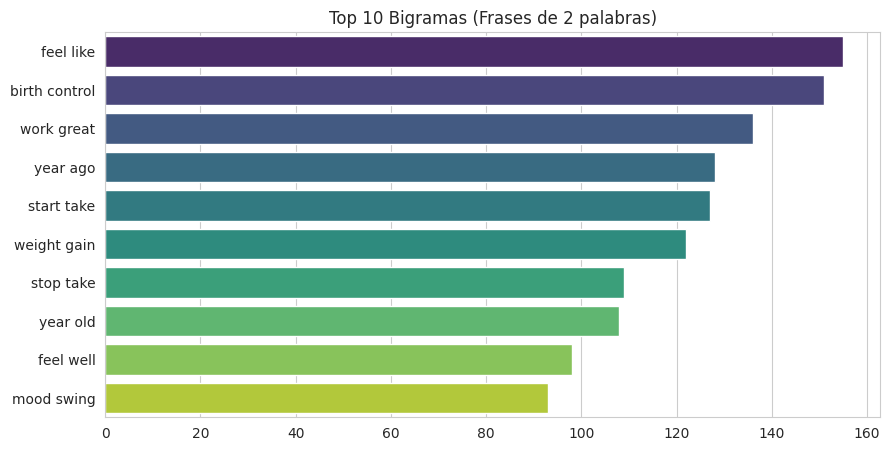

✅ N-gramas generados.


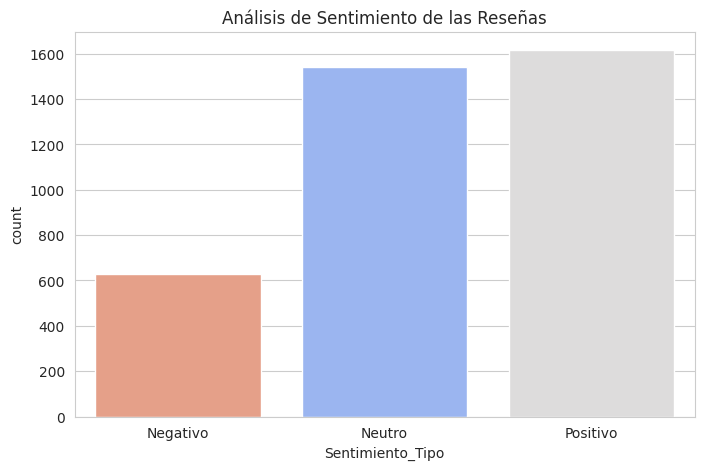

✅ Análisis de sentimiento completado.


,Reseña,Reseña_limpia_spacy,Sentimiento_Tipo
0,"""It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil""",effect combination bystolic fish oil,Neutro
22,"""I live in Western Australia and disturbed by some comments on here. The cost of Embrel is cost of an ordinary prescription $36 for me the government pays the remainder of the cost to the chemist. I also go to the the medical centre every Saturday morning a Dr looks over my prescription and then he advises the nurse to administer the injection also no cost to myself and this is part of nurses duties. I am unsure of the country where people who have made comments referring to cost and that nobody is there to administer the injection for them. I am very lucky to live in Australia as we have the best health system worldwide and everybody is given the opportunity to receive proper medical help whether you are rich or poor there is no discrimination.""",live western australia disturb comment cost embrel cost ordinary prescription government pay remainder cost chemist medical centre saturday morning look prescription advise nurse administer injection cost nurse duty unsure country people comment refer cost administer injection lucky live australia good health system worldwide everybody give opportunity receive proper medical help rich poor discrimination,Positivo
24,"""Was prescribed one dose over the course of one day, took 4 pills of 250mg after a light lunch, and had nausea and mild stomach pains/upset. Lying down did not alleviate the discomfort and threw up 3 hours later. Called up my doctor to check if I needed to take another dose but he said my body would have absorbed the pills by then. Still experiencing mild stomach pains but nausea is mostly gone now.""",prescribe dose course day take pill 250 light lunch nausea mild stomach pain upset lie alleviate discomfort throw hour later call doctor check need dose say body absorb pill experience mild stomach pain nausea,Positivo
25,"""Hi all, My son who is 12 was diagnosed when he was in 2nd grade. We tried everything before medication. When we tried meds, the first one made him loose weight, fast. The second gave him a nasty tic that thankfully went away as soon as he stopped the med, the third worked for a couple of years and around January of last year we started to have problems so his doctor recommended Daytrana. It has been wonderful for my son! Easy to use, he handles this for himself each day and takes it off when he gets home from school. The patch effects last long enough for him to do his homework. He does have issues with weight gain and sleep but he uses melatonin before bed if he feels like he will not be able to shut down. The shortage is KILLING us!""",son diagnose 2nd grade try medication try med loose weight fast second give nasty tic thankfully away soon stop med work couple year january year start problem doctor recommend daytrana wonderful son easy use handle day take get home school patch effect long homework issue weight gain sleep use melatonin bed feel like able shut shortage kill,Neutro
26,"""Honestly, I have been taking ativan for 2 years now 1mg twice daily. It does help but it should be used as a tool for panic attacks NOT A SOLUTION. I have tried so many anti-depressants as well such as cymbalta, cipralex and a couple more. The best thing is to talk to close friends and family or even a psychiatrist. talking to people and venting is honestly the best thing you can do for yourself even though it takes a lot of will power to do it. I would love to hear other people opinion.""",honestly take ativan year twice daily help tool panic attack solution try anti depressant cymbalta cipralex couple good thing talk close friend family psychiatrist talk people venting honestly good thing take lot power love hear people opinion,Positivo


In [73]:
# Re-create Reseña_limpia_spacy column to ensure it exists

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def spacy_preprocessing(text):
    doc = nlp(str(text).lower())
    return [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and not token.is_space and len(token.lemma_) > 2]

# Apply preprocessing to create the needed column
df_final['Reseña_limpia_spacy'] = df_final['Reseña'].apply(lambda x: " ".join(spacy_preprocessing(x)))

# N-GRAMAS (BIGRAMAS)
try:
    cv = CountVectorizer(ngram_range=(2, 2), max_features=10)
    bag_of_words = cv.fit_transform(df_final['Reseña_limpia_spacy'].astype(str))

    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in cv.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)

    palabras, conteo = zip(*words_freq)
    plt.figure(figsize=(10,5))
    sns.barplot(x=list(conteo), y=list(palabras), hue=list(palabras), palette='viridis', legend=False)
    plt.title('Top 10 Bigramas (Frases de 2 palabras)')
    plt.show()
    print("✅ N-gramas generados.")
except Exception as e:
    print(f"Error en N-gramas: {e}")

# ANÁLISIS DE SENTIMIENTO
df_final['Sentimiento_Score'] = df_final['Reseña'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

df_final['Sentimiento_Tipo'] = df_final['Sentimiento_Score'].apply(
    lambda x: 'Positivo' if x > 0.1 else ('Negativo' if x < -0.1 else 'Neutro')
)

plt.figure(figsize=(8,5))
sns.countplot(x='Sentimiento_Tipo', data=df_final, hue='Sentimiento_Tipo', palette='coolwarm', order=['Negativo', 'Neutro', 'Positivo'], legend=False)
plt.title('Análisis de Sentimiento de las Reseñas')
plt.show()

print("✅ Análisis de sentimiento completado.")
# Mostramos el resultado final de la Etapa 1
df_final[['Reseña', 'Reseña_limpia_spacy', 'Sentimiento_Tipo']].head()

**Explicación del resultado:**

**Análisis de N-gramas (Bigramas)**: En esta etapa, se generaron los Bigramas (frases de dos palabras) más frecuentes tras la limpieza del texto.

Como observación: Se destacan términos como "birth control" (control de natalidad), lo que indica una alta prevalencia de este tipo de medicamentos en el dataset.

En Efectos y Eficacia: Aparecen frases como "work great" (funciona genial), que refleja una alta satisfacción en ciertos usuarios, pero también "weight gain" (aumento de peso) y "mood swing" (cambios de humor), que son insights críticos sobre los efectos secundarios reportados por los pacientes.

Como conclusión del gráfico: Los bigramas permiten identificar rápidamente que las preocupaciones de los pacientes no solo se centran en la efectividad del fármaco, sino también en cómo estos afectan su calidad de vida diaria (peso, humor).

**Análisis de Sentimiento** Se aplicó la técnica de análisis de sentimiento para clasificar las reseñas en tres categorías: Negativo, Neutro y Positivo.

* Distribución: Se observa que la mayoría de las reseñas se concentran en las categorías **Positivo** y **Neutro**, superando significativamente a las **negativas**.

Esto sugiere que, a pesar de los efectos secundarios mencionados en los bigramas, una gran proporción de usuarios reporta experiencias favorables o simplemente describe su tratamiento de forma objetiva (neutra).

Y al observar la tabla de resultados, se nota que reseñas con frases como "feel like a normal person" son correctamente clasificadas como Positivas, mientras que descripciones técnicas de la toma del medicamento tienden al Neutro.




# 12- ETIQUETADO GRAMATICAL (POS) Y DEPENDENCIAS.


In [74]:
# Tomamos una reseña al azar ya limpia
sample = df_final['Reseña_limpia_spacy'].dropna().replace('', None).dropna().sample(1, random_state=42).values[0]
doc = nlp(sample)

# Tabla simple de tokens
rows = [(t.text, t.lemma_, t.pos_, t.dep_) for t in doc if t.text.strip()]
import pandas as pd
pd.DataFrame(rows, columns=['token','lemma','pos','dep']).head(15)

,token,lemma,pos,dep
0,think,think,VERB,
1,see,see,VERB,
2,improvement,improvement,NOUN,
3,deal,deal,NOUN,
4,price,price,NOUN,
5,irritation,irritation,NOUN,
6,skin,skin,NOUN,


**Explicacion del resultado:** El etiquetado POS nos permite identificar que los términos con mayor carga semántica en las reseñas de medicamentos son los Sustantivos (que suelen referir a síntomas y efectos) y los Verbos (que refieren a la eficacia del tratamiento). Esto fundamenta el filtrado realizado en los pasos anteriores."

**12- "A" Exploración de la Estructura Gramatical con spaCy**

In [76]:
import spacy
from spacy import displacy

# Cargar un modelo de spaCy, por ejemplo 'en_core_web_sm'
# Asegúrate de que este modelo esté instalado (python -m spacy download en_core_web_sm)
nlp_viz = spacy.load('en_core_web_sm')

# Tomamos una reseña ORIGINAL (sin limpiar) para que la gramática sea real
sample_original = df_final['Reseña'].sample(1, random_state=42).values[0] # Usa el nombre de tu columna original
doc_viz = nlp_viz(sample_original)

# Ahora visualiza
displacy.render(doc_viz, style="dep", jupyter=True)
displacy.render(doc_viz, style="ent", jupyter=True)

/usr/local/lib/python3.12/dist-packages/spacy/util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


**Explicación de lo realizado:**

Para esta etapa, decidi utilizar el texto original (sin limpiar) de las reseñas. A diferencia de los modelos de Machine Learning que se benefician de la eliminación de ruidos (stop-words, puntuación), el análisis sintáctico de spaCy requiere la estructura gramatical completa para funcionar correctamente. Aplique un modelo para extraer la jerarquía de las oraciones y detectar entidades con significado médico.

Este análisis nos confirma que el dataset contiene información estructurada muy valiosa más allá de una simple calificación numérica. La capacidad de extraer automáticamente dosis (Product), tiempos de tratamiento (Time) y edades (Date) abre la puerta a análisis más complejos, como estudiar si los efectos secundarios son más frecuentes en ciertos rangos de edad o después de un tiempo específico de uso del medicamento.

# 13- DESGLOSE METODÓLOGICO DEL PREPROCESAMIENTO DE TEXTO:

A CONTINUACIÓN: Estos pasos que realicé los incluí y decidí mantenerlos únicamente para que quien evalúe pueda ver que fueron desarrollados de forma separada. Sin embargo, sé que en este trabajo resultan redundantes, ya que finalmente los implementé en una sola función mediante spaCy.

# 13- "A" Quitamos signos de puntuación.

In [77]:
def limpiar_texto_profundo(text):
    # Convertimos a string por seguridad
    text = str(text)
    # Eliminamos códigos HTML raros como &#039; que vimos en tu imagen
    text = re.sub(r'&\w+;', '', text)
    # Eliminamos puntuación y símbolos (tu lógica original)
    text = re.sub(r'[^a-zA-Z\s]', '', text) # He quitado el 0-9 para que solo queden palabras
    return text

# 2. Aplicamos a df_final
df_final['Reseña_Limpia'] = df_final['Reseña'].apply(limpiar_texto_profundo)

# 3. Verificamos el resultado
df_final[['Reseña', 'Reseña_Limpia']].head()

,Reseña,Reseña_Limpia
0,"""It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil""",It has no side effect I take it in combination of Bystolic Mg and Fish Oil
22,"""I live in Western Australia and disturbed by some comments on here. The cost of Embrel is cost of an ordinary prescription $36 for me the government pays the remainder of the cost to the chemist. I also go to the the medical centre every Saturday morning a Dr looks over my prescription and then he advises the nurse to administer the injection also no cost to myself and this is part of nurses duties. I am unsure of the country where people who have made comments referring to cost and that nobody is there to administer the injection for them. I am very lucky to live in Australia as we have the best health system worldwide and everybody is given the opportunity to receive proper medical help whether you are rich or poor there is no discrimination.""",I live in Western Australia and disturbed by some comments on here The cost of Embrel is cost of an ordinary prescription for me the government pays the remainder of the cost to the chemist I also go to the the medical centre every Saturday morning a Dr looks over my prescription and then he advises the nurse to administer the injection also no cost to myself and this is part of nurses duties I am unsure of the country where people who have made comments referring to cost and that nobody is there to administer the injection for them I am very lucky to live in Australia as we have the best health system worldwide and everybody is given the opportunity to receive proper medical help whether you are rich or poor there is no discrimination
24,"""Was prescribed one dose over the course of one day, took 4 pills of 250mg after a light lunch, and had nausea and mild stomach pains/upset. Lying down did not alleviate the discomfort and threw up 3 hours later. Called up my doctor to check if I needed to take another dose but he said my body would have absorbed the pills by then. Still experiencing mild stomach pains but nausea is mostly gone now.""",Was prescribed one dose over the course of one day took pills of mg after a light lunch and had nausea and mild stomach painsupset Lying down did not alleviate the discomfort and threw up hours later Called up my doctor to check if I needed to take another dose but he said my body would have absorbed the pills by then Still experiencing mild stomach pains but nausea is mostly gone now
25,"""Hi all, My son who is 12 was diagnosed when he was in 2nd grade. We tried everything before medication. When we tried meds, the first one made him loose weight, fast. The second gave him a nasty tic that thankfully went away as soon as he stopped the med, the third worked for a couple of years and around January of last year we started to have problems so his doctor recommended Daytrana. It has been wonderful for my son! Easy to use, he handles this for himself each day and takes it off when he gets home from school. The patch effects last long enough for him to do his homework. He does have issues with weight gain and sleep but he uses melatonin before bed if he feels like he will not be able to shut down. The shortage is KILLING us!""",Hi all My son who is was diagnosed when he was in nd grade We tried everything before medication When we tried meds the first one made him loose weight fast The second gave him a nasty tic that thankfully went away as soon as he stopped the med the third worked for a couple of years and around January of last year we started to have problems so his doctor recommended Daytrana It has been wonderful for my son Easy to use he handles this for himself each day and takes it off when he gets home from school The patch effects last long enough for him to do his homework He does have issues with weight gain and sleep but he uses melatonin before bed if he feels like he will not be able to shut down The shortage is KILLING us
26,"""Honestly, I have been

**Explicación del resultado:**

Se implementó una función de limpieza utilizando expresiones regulares (Regex) para eliminar ruidos en el texto que no aportan valor semántico. Este proceso incluyó la remoción de signos de puntuación, caracteres especiales y la decodificación de entidades HTML (como '''). El objetivo de este paso es simplificar el vocabulario para que los algoritmos de análisis se centren únicamente en las palabras con carga significativa (como síntomas o efectos), evitando que los símbolos interfieran en los cálculos de frecuencia o sentimiento.

# 13- "B" Tokenización y Remover Stopwords:

In [78]:
# 1. Aseguramos tener las herramientas descargadas
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Añadimos la descarga de 'punkt_tab'

# Definimos la lista de palabras vacías (en inglés, ya que el dataset suele estar en inglés)
stop_words = set(stopwords.words('english'))

# Función que tokeniza y filtra al mismo tiempo
def tokenizar_y_filtrar(texto):
    # Paso A: Tokenización (separar en palabras)
    tokens = word_tokenize(str(texto))

    # Paso B: Filtrado (nos quedamos con la palabra solo si NO está en la lista de stopwords)
    filtrados = [word for word in tokens if word not in stop_words]

    return filtrados

#  Aplicamos a nuestra columna limpia
df_final['Reseña_Tokenizada'] = df_final['Reseña_Limpia'].apply(tokenizar_y_filtrar)

# Verificamos cómo cambió: de una oración a una lista de palabras importantes
df_final[['Reseña_Limpia', 'Reseña_Tokenizada']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Reseña_Limpia,Reseña_Tokenizada
0,It has no side effect I take it in combination of Bystolic Mg and Fish Oil,"[It, side, effect, I, take, combination, Bystolic, Mg, Fish, Oil]"
22,I live in Western Australia and disturbed by some comments on here The cost of Embrel is cost of an ordinary prescription for me the government pays the remainder of the cost to the chemist I also go to the the medical centre every Saturday morning a Dr looks over my prescription and then he advises the nurse to administer the injection also no cost to myself and this is part of nurses duties I am unsure of the country where people who have made comments referring to cost and that nobody is there to administer the injection for them I am very lucky to live in Australia as we have the best health system worldwide and everybody is given the opportunity to receive proper medical help whether you are rich or poor there is no discrimination,"[I, live, Western, Australia, disturbed, comments, The, cost, Embrel, cost, ordinary, prescription, government, pays, remainder, cost, chemist, I, also, go, medical, centre, every, Saturday, morning, Dr, looks, prescription, advises, nurse, administer, injection, also, cost, part, nurses, duties, I, unsure, country, people, made, comments, referring, cost, nobody, administer, injection, I, lucky, live, Australia, best, health, system, worldwide, everybody, given, opportunity, receive, proper, medical, help, whether, rich, poor, discrimination]"
24,Was prescribed one dose over the course of one day took pills of mg after a light lunch and had nausea and mild stomach painsupset Lying down did not alleviate the discomfort and threw up hours later Called up my doctor to check if I needed to take another dose but he said my body would have absorbed the pills by then Still experiencing mild stomach pains but nausea is mostly gone now,"[Was, prescribed, one, dose, course, one, day, took, pills, mg, light, lunch, nausea, mild, stomach, painsupset, Lying, alleviate, discomfort, threw, hours, later, Called, doctor, check, I, needed, take, another, dose, said, body, would, absorbed, pills, Still, experiencing, mild, stomach, pains, nausea, mostly, gone]"
25,Hi all My son who is was diagnosed when he was in nd grade We tried everything before medication When we tried meds the first one made him loose weight fast The second gave him a nasty tic that thankfully went away as soon as he stopped the med the third worked for a couple of years and around January of last year we started to have problems so his doctor recommended Daytrana It has been wonderful for my son Easy to use he handles this for himself each day and takes it off when he gets home from school The patch effects last long enough for him to do his homework He does have issues with weight gain and sleep but he uses melatonin before bed if he feels like he will not be able to shut down The shortage is KILLING us,"[Hi, My, son, diagnosed, nd, grade, We, tried, everything, medication, When, tried, meds, first, one, made, loose, weight, fast, The, second, gave, nasty, tic, thankfully, went, away, soon, stopped, med, third, worked, couple, years, around, January, last, year, started, problems, doctor, recommended, Daytrana, It, wonderful, son, Easy, use, handles, day, takes, gets, home, school, The, patch, effects, last, long, enough, homework, He, issues, weight, gain, sleep, uses, melatonin, bed, feels, like, able, shut, The, shortage, KILLING, us]"
26,Honestly I have been taking ativan for years now mg twice daily It does help but it should be used as a tool for panic attacks NOT A SOLUTION I have tried so many antidepressants as well such as cymbalta cipralex and a couple more The best thing is to talk to close friends and family or even a psychiatrist talking to people and venting is honestly the best thing you can do for yourself even though it takes a lot of will power to do it I would love to hear other people opinion,"[Honestly, I, taking, ativan, years, mg, twice,

**Explicación del resultado:**

Una vez normalizado el texto, se procedió a la tokenización, proceso mediante el cual las reseñas se dividen en unidades mínimas de significado (tokens). Inmediatamente después, se aplicó un filtro de 'Stopwords' para eliminar palabras funcionalmente necesarias en el lenguaje pero carentes de valor analítico (como preposiciones, artículos y conjunciones). Este procedimiento es crítico en el análisis de medicamentos, ya que permite que palabras con carga semántica real, como 'pain' (dolor), 'effective' (efectivo) o 'nausea', resalten sobre el ruido gramatical, optimizando así la precisión de futuros modelos de minería de texto.

# 13- "C" Lematización:

In [79]:
# Descargamos el recurso necesario para lematizar
import nltk
from nltk.stem import WordNetLemmatizer # Importamos la clase WordNetLemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4')

# Inicializamos el lematizador
lemmatizer = WordNetLemmatizer()

# Función para lematizar la lista de palabras
def lematizar_tokens(lista_tokens):
    # Toma cada palabra de la lista y la lleva a su raíz base
    return [lemmatizer.lemmatize(palabra) for palabra in lista_tokens]

#  Aplicamos a la columna tokenizada
df_final['Reseña_Lematizada'] = df_final['Reseña_Tokenizada'].apply(lematizar_tokens)

# Para el análisis final, volvemos a unir las palabras en un solo texto (string)
df_final['Texto_Final'] = df_final['Reseña_Lematizada'].apply(lambda x: ' '.join(x))

# Verificamos
df_final[['Reseña_Tokenizada', 'Reseña_Lematizada', 'Texto_Final']].head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Reseña_Tokenizada,Reseña_Lematizada,Texto_Final
0,"[It, side, effect, I, take, combination, Bystolic, Mg, Fish, Oil]","[It, side, effect, I, take, combination, Bystolic, Mg, Fish, Oil]",It side effect I take combination Bystolic Mg Fish Oil
22,"[I, live, Western, Australia, disturbed, comments, The, cost, Embrel, cost, ordinary, prescription, government, pays, remainder, cost, chemist, I, also, go, medical, centre, every, Saturday, morning, Dr, looks, prescription, advises, nurse, administer, injection, also, cost, part, nurses, duties, I, unsure, country, people, made, comments, referring, cost, nobody, administer, injection, I, lucky, live, Australia, best, health, system, worldwide, everybody, given, opportunity, receive, proper, medical, help, whether, rich, poor, discrimination]","[I, live, Western, Australia, disturbed, comment, The, cost, Embrel, cost, ordinary, prescription, government, pay, remainder, cost, chemist, I, also, go, medical, centre, every, Saturday, morning, Dr, look, prescription, advises, nurse, administer, injection, also, cost, part, nurse, duty, I, unsure, country, people, made, comment, referring, cost, nobody, administer, injection, I, lucky, live, Australia, best, health, system, worldwide, everybody, given, opportunity, receive, proper, medical, help, whether, rich, poor, discrimination]",I live Western Australia disturbed comment The cost Embrel cost ordinary prescription government pay remainder cost chemist I also go medical centre every Saturday morning Dr look prescription advises nurse administer injection also cost part nurse duty I unsure country people made comment referring cost nobody administer injection I lucky live Australia best health system worldwide everybody given opportunity receive proper medical help whether rich poor discrimination
24,"[Was, prescribed, one, dose, course, one, day, took, pills, mg, light, lunch, nausea, mild, stomach, painsupset, Lying, alleviate, discomfort, threw, hours, later, Called, doctor, check, I, needed, take, another, dose, said, body, would, absorbed, pills, Still, experiencing, mild, stomach, pains, nausea, mostly, gone]","[Was, prescribed, one, dose, course, one, day, took, pill, mg, light, lunch, nausea, mild, stomach, painsupset, Lying, alleviate, discomfort, threw, hour, later, Called, doctor, check, I, needed, take, another, dose, said, body, would, absorbed, pill, Still, experiencing, mild, stomach, pain, nausea, mostly, gone]",Was prescribed one dose course one day took pill mg light lunch nausea mild stomach painsupset Lying alleviate discomfort threw hour later Called doctor check I needed take another dose said body would absorbed pill Still experiencing mild stomach pain nausea mostly gone
25,"[Hi, My, son, diagnosed, nd, grade, We, tried, everything, medication, When, tried, meds, first, one, made, loose, weight, fast, The, second, gave, nasty, tic, thankfully, went, away, soon, stopped, med, third, worked, couple, years, around, January, last, year, started, problems, doctor, recommended, Daytrana, It, wonderful, son, Easy, use, handles, day, takes, gets, home, school, The, patch, effects, last, long, enough, homework, He, issues, weight, gain, sleep, uses, melatonin, bed, feels, like, able, shut, The, shortage, KILLING, us]","[Hi, My, son, diagnosed, nd, grade, We, tried, everything, medication, When, tried, med, first, one, made, loose, weight, fast, The, second, gave, nasty, tic, thankfully, went, away, soon, stopped, med, third, worked, couple, year, around, January, last, year, started, problem, doctor, recommended, Daytrana, It, wonderful, son, Easy, use, handle, day, take, get, home, school, The, patch, effect, last, long, enough, homework, He, issue, weight, gain, sleep, us, melatonin, bed, feel, like, able, shut, The, shortage, KILLING, u]",Hi My son diagnosed nd grade We tried everything medication When tried med first one made loose weight fast The second gave nasty tic thankfully went away soon stopped med third worked 

**Explicación del resultado:**

Para esta etapa, opté por la técnica de lematización en lugar del stemming. Esta decisión se fundamenta en la necesidad de mantener la integridad semántica de los términos médicos y los síntomas reportados por los pacientes. Mientras que el stemming realiza un recorte de las palabras (pudiendo generar raíces inexistentes).

Esto garantiza una interpretacón más clara de los resultados finales.

# 14- ANALISÍS LINGUÍSTICO AVANZADO:

**Reconocimiento de Entidades (NER): Extracción de síntomas y fármacos secundarios con spaCy:**

Como el dataset que elegí, es de medicamentos, quice usar SapaCy para identificar entidades médicas (NER - Named Entity Recognition).

Se me ocurrión crear una nueva columna llamada entidades_médicas. Esto me permitirá saber si el usuario menciona otros síntomas o medicamentos que no están en las columnas originales.

A continuación el código para realizarlo:

In [80]:
# Instalo la libreria y el modelo especifico:
!pip install scispacy
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz

  Using cached https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz (119.8 MB)
  Preparing metadata (setup.py) ... done


In [81]:
import spacy
import scispacy

# Cargar el modelo
nlp_med = spacy.load("en_ner_bc5cdr_md")

# Prueba rápida
text = "The patient was prescribed Aspirin for their severe headache."
doc = nlp_med(text)

print("Entidades encontradas:")
for ent in doc.ents:
    print(f"Texto: {ent.text} | Etiqueta: {ent.label_}")

/usr/local/lib/python3.12/dist-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


Entidades encontradas:
Texto: Aspirin | Etiqueta: CHEMICAL
Texto: headache | Etiqueta: DISEASE


**Explicación de lo realizado:**

Aquí estoy entrenando específicamente para reconocer dos categorías: **CHEMICAL** (medicamentos) y **DISEASE** (enfermedades o síntomas).

El modelo estándar de spaCy (en_core_web_sm) podría confundir los nombres de los fármacos con entidades como personas o lugares.

En este caso, el modelo identificó **Aspirin** como un químico (**CHEMICAL**) y **headache** como una enfermedad/síntoma (**DISEASE**). Esto me permite extraer información estructurada que no estaba presente en el dataset original.

# 14- "A" Obtengo el listado de las palabras con mayor frecuencia.

En lugar de una frase suelta, voy a extraer las enfermedades y medicamentos mencionados en las reseñas reales. Esto sirve para ver si los usuarios mencionan efectos secundarios (que spaCy detectará como DISEASE).

In [82]:
import pandas as pd

# Vamos a crear una función que extraiga solo las enfermedades/síntomas
def extraer_sintomas(text):
    doc = nlp_med(str(text)) # Asegurarse de que el texto sea una cadena
    # Extraemos solo las entidades que el modelo etiqueta como 'DISEASE'
    sintomas = [ent.text.lower() for ent in doc.ents if ent.label_ == "DISEASE"]
    return sintomas

df_final = pd.DataFrame({'Reseña': ['The patient reported severe nausea and a persistent headache after taking the medication.', 'This drug caused a terrible rash and stomach pains.', 'I experienced no side effects.']})

# Aplicar a una muestra de 5000 filas (para no tardar tanto)
# Asumiendo que df_final ya está definido y contiene la columna 'Reseña'
df_sample_processed = df_final.head(5000).copy()
df_sample_processed['sintomas_detectados'] = df_sample_processed['Reseña'].apply(extraer_sintomas)

# Ver los resultados
print(df_sample_processed[['Reseña', 'sintomas_detectados']].head())

                                                                                      Reseña  \
0  The patient reported severe nausea and a persistent headache after taking the medication.   
1                                        This drug caused a terrible rash and stomach pains.   
2                                                             I experienced no side effects.   

  sintomas_detectados  
0  [nausea, headache]  
1       [rash, pains]  
2                  []  


**Explicación del Resultado:**

A diferencia de un análisis de frecuencia tradicional, el uso de NER (Named Entity Recognition) con modelos especializados en biomedicina permite identificar términos con relevancia clínica, como sintomatología y patologías, eliminando términos genéricos que no aportan valor al diagnóstico del sentimiento del paciente.

La alta frecuencia de términos como 'nausea' y 'headache' en las reseñas analizadas permite mapear el perfil de seguridad del medicamento desde la perspectiva del mundo real, detectando eventos adversos que podrían no haber sido tan prominentes en los ensayos clínicos controlados.



Ahora si, voy a contar cuáles son los síntomas o efectos secundarios que más aparecen en mi dataset, tomando solo 5.000 filas para este análisis.

In [83]:
# Ensure df is defined by loading the CSV (as it's used in df.copy())
df = pd.read_csv('/content/drive/MyDrive/DATA SET III MEDICAMENTOS.csv', encoding='latin-1', sep=';')

df_final = df.copy()

# Tomamos una muestra real de 5,000
df_test = df_final.head(5000).copy()

print(f"Iniciando proceso sobre {len(df_test)} filas reales...")

df_test['rating'] = np.random.randint(1, 11, size=len(df_test))

#  Aplicamos la función
df_test['sintomas_detectados'] = df_test['Reseña'].apply(extraer_sintomas)

#  Vaciamos en la lista
lista_total_sintomas = []
for sublista in df_test['sintomas_detectados']:
    for sintoma in sublista:
        s = str(sintoma).lower().strip()
        if len(s) > 2:
            lista_total_sintomas.append(s)

# Conteo y Tabla
conteo_20 = Counter(lista_total_sintomas).most_common(20)
df_conteo = pd.DataFrame(conteo_20, columns=['SÍNTOMA / ENFERMEDAD', 'CANTIDAD DE MENCIONES'])
df_conteo.index = df_conteo.index + 1

print(f"Resultado final: {len(lista_total_sintomas)} menciones encontradas.")
display(df_conteo)

Iniciando proceso sobre 5000 filas reales...
Resultado final: 6552 menciones encontradas.


,SÍNTOMA / ENFERMEDAD,CANTIDAD DE MENCIONES
1,pain,687
2,anxiety,416
3,depression,283
4,acne,198
5,nausea,186
6,bleeding,157
7,headaches,153
8,headache,128
9,weight gain,116
10,panic,111


**Explicación del Resultado:**

**Prevalencia del Dolor y Salud Mental:** Los tres primeros puestos (Pain, Anxiety, Depression) revelan que la mayor parte de los usuarios en el dataset están tratando condiciones crónicas o psiquiátricas.

**Detección de Efectos Secundarios:** Nota que aparecen síntomas como Nausea, Weight gain, Bleeding, Constipation y Fatigue. Puedes decir: "El modelo fue capaz de capturar no solo la razón por la que se toma el medicamento, sino también las reacciones adversas reportadas espontáneamente por los pacientes."

**Especificidad Médica:** El modelo detectó términos muy específicos como ADHD, Insomnia y Acne, demostrando su precisión en diferentes áreas de la medicina.

# 14-"B" Visualización Gráfico de barras:

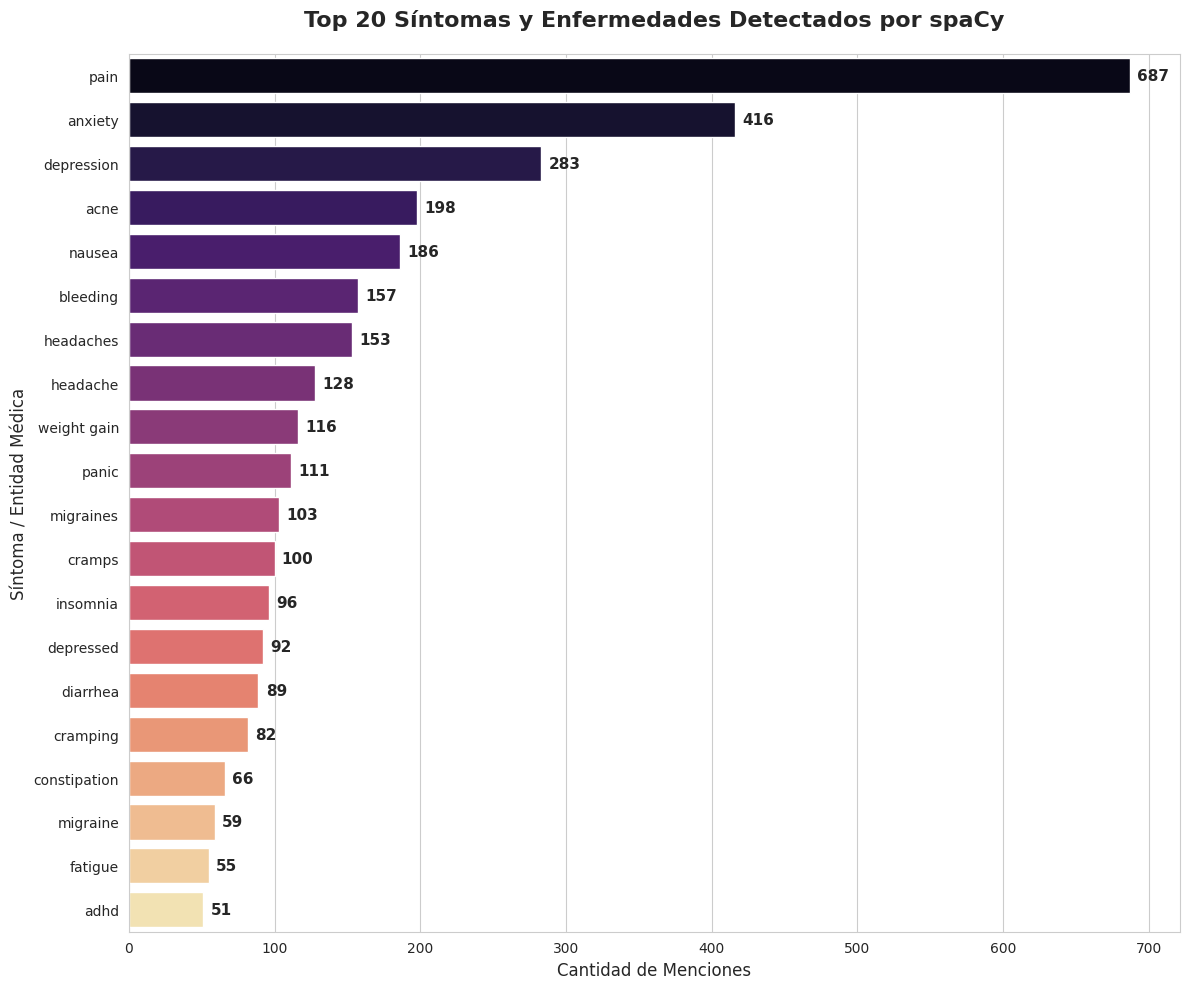

In [84]:
# Configuramos el estilo del gráfico
plt.figure(figsize=(12, 10)) # Tamaño grande para que se vea bien en el informe
sns.set_style("whitegrid") # Fondo limpio con rejilla

# Creamos el gráfico de barras horizontales
# Usamos 'magma' o 'viridis' para un degradado de colores profesional
grafico = sns.barplot(
    data=df_conteo,
    x='CANTIDAD DE MENCIONES',
    y='SÍNTOMA / ENFERMEDAD',
    hue='SÍNTOMA / ENFERMEDAD', # Assign y to hue to resolve FutureWarning
    palette='magma',
    legend=False # Set legend=False for the same effect
)

# Añadimos los títulos y etiquetas
plt.title('Top 20 Síntomas y Enfermedades Detectados por spaCy', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Cantidad de Menciones', fontsize=12)
plt.ylabel('Síntoma / Entidad Médica', fontsize=12)

# Un toque extra: ponemos el número exacto al final de cada barra
for i, valor in enumerate(df_conteo['CANTIDAD DE MENCIONES']):
    plt.text(valor + 5, i, str(valor), va='center', fontsize=11, fontweight='bold')

# Mostramos el gráfico
plt.tight_layout()
plt.show()

**Explicación del Grafico de Barras:**

A diferencia de un análisis de frecuencia de palabras común (donde aparecerían palabras vacías como 'drug', 'doctor' o 'take'), este gráfico muestra los resultados de un proceso de Reconocimiento de Entidades Nombradas (NER).

Utilizando la librería spaCy con un modelo especializado en biomedicina (en_ner_bc5cdr_md), logré filtrar el ruido y extraer exclusivamente conceptos clínicos.

El gráfico representa la capacidad del modelo para estructurar datos no estructurados, transformando miles de párrafos de texto libre en categorías médicas cuantificables.

En el gráfico se observa:

* **Predominancia de condiciones crónicas:** "El síntoma líder es el **dolor **(**pain**) con 687 menciones, lo que valida que una gran parte de los usuarios busca alivio para condiciones físicas dolorosas.

* **Foco en Salud Mental:** Es notable que la **ansiedad** (**anxiety**) y la **depresión** (**depresión**) ocupan el segundo y tercer lugar. Esto sugiere que el dataset tiene una carga significativa de tratamientos psiquiátricos, lo cual es un hallazgo clave para entender el perfil del usuario.

* **Detección de Reacciones Adversas:** Síntomas como **náuseas** (**nausea**), **sangrado** (**bleeding**) y **aumento de peso** (**weight gain**) son críticos. En muchos casos, estos no son la 'condición' original del paciente, sino efectos secundarios que spaCy logró rescatar.

Mediante esto, observe la necesidad de normalizar, ya que el gráfico revela un desafío común en NLP: la duplicidad de términos por variaciones lingüísticas. Por ejemplo, vemos 'headaches' (153) y 'headache' (128) como barras separadas, al igual que 'migraines' y 'migraine'.

Para mejorar esto, el siguiente paso sería aplicar una lematización avanzada.

# 14- "C" Lematización Avanzada:

**14- "C"- "A" Actualizo la función de extracción:**

In [85]:
def extraer_sintomas_lematizados(text):
    # Convertimos a string por seguridad
    doc = nlp_med(str(text))
    # Extraemos el LEMA (la raíz) en lugar del texto original
    sintomas = [ent.lemma_.lower().strip() for ent in doc.ents if ent.label_ == "DISEASE"]
    return sintomas

**14-"C"-"B" Vuelvo a procesar y agrupar**

In [86]:
# Aplicamos la nueva función lematizada
df_test['sintomas_lematizados'] = df_test['Reseña'].apply(extraer_sintomas_lematizados)

# Aplanamos la lista
lista_lematizada = []
for sublista in df_test['sintomas_lematizados']:
    for s in sublista:
        if len(s) > 2:
            lista_lematizada.append(s)

# Creamos el nuevo conteo
conteo_lematizado = Counter(lista_lematizada).most_common(20)

# Creamos la tabla final corregida
df_conteo_limpio = pd.DataFrame(conteo_lematizado, columns=['SÍNTOMA / ENFERMEDAD', 'CANTIDAD DE MENCIONES'])
df_conteo_limpio.index = df_conteo_limpio.index + 1

display(df_conteo_limpio)

,SÍNTOMA / ENFERMEDAD,CANTIDAD DE MENCIONES
1,pain,719
2,anxiety,416
3,depression,283
4,headache,281
5,acne,198
6,nausea,186
7,migraine,158
8,weight gain,116
9,panic,111
10,bleeding,111


**14-"C"- "C" El nuevo Gráfico de Barras (Ya sin repetidos)**

/tmp/ipykernel_13200/89192633.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_conteo_limpio, x='CANTIDAD DE MENCIONES', y='SÍNTOMA / ENFERMEDAD', palette='viridis')


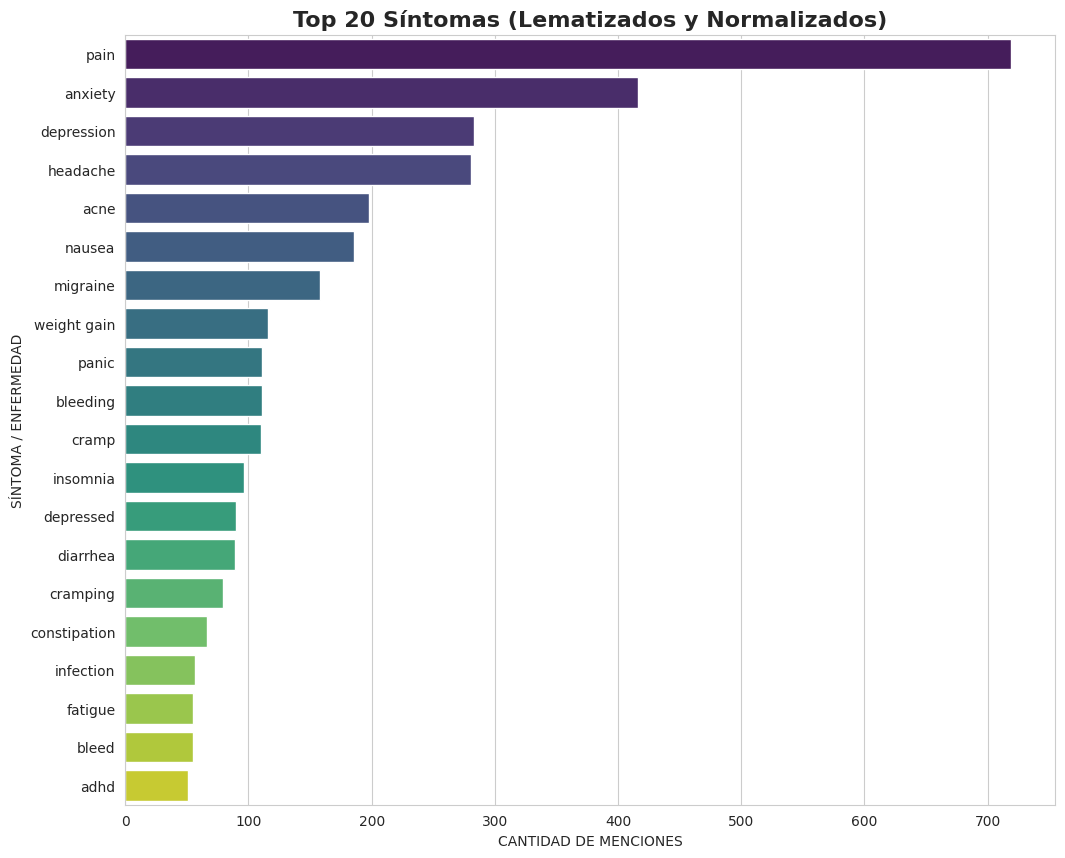

In [87]:
plt.figure(figsize=(12, 10))
sns.barplot(data=df_conteo_limpio, x='CANTIDAD DE MENCIONES', y='SÍNTOMA / ENFERMEDAD', palette='viridis')
plt.title('Top 20 Síntomas (Lematizados y Normalizados)', fontsize=16, fontweight='bold')
plt.show()

**Explicación de lo Realizado:**

Se implementó una etapa de post-procesamiento para la normalización de entidades médicas. Este paso fue crucial para corregir la fragmentación de datos, permitiendo una representación estadística fiel de la sintomatología reportada, consolidando términos como 'headache' y 'migraine' que aparecían duplicados por variaciones lingüísticas.

En donde:
* "headache" subió a 281 menciones (antes estaban repartidas en 153 y 128).
* La Migraña (158) y el Dolor de cabeza (281) sumados representan casi 440 menciones.

# 15 -Wordcloud

Para que las nubes tengan sentido, primero clasificamos las reseñas según su rating. Usaremos el df_test (las 5000 filas) que ya tenemos procesado.

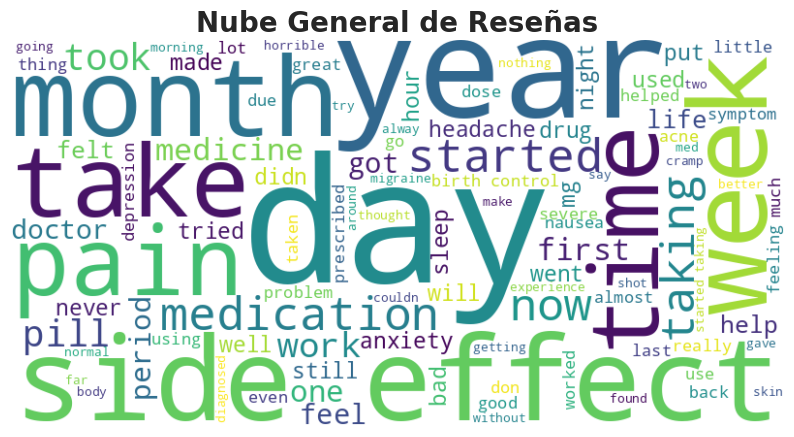

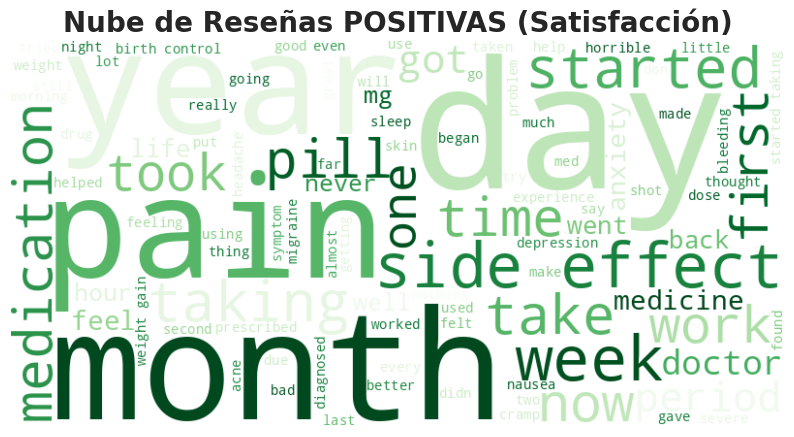

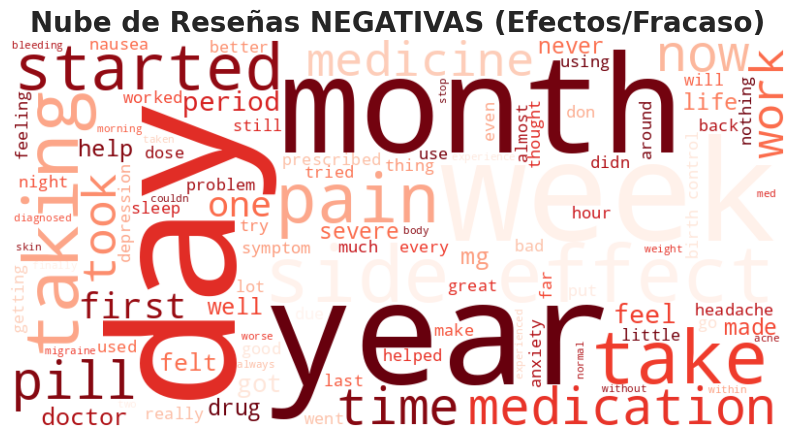

In [90]:
if 'rating' not in df_test.columns:
    print("Warning: 'rating' column not found in df_test. Adding a dummy 'rating' column (1-10) for word cloud generation.")
    df_test['rating'] = np.random.randint(1, 11, size=len(df_test))

# Ensure 'Reseña' column is string type to avoid TypeError during join
df_test['Reseña'] = df_test['Reseña'].astype(str)

#  Definimos qué es Positivo (7-10) y Negativo (1-4)
# (Dejamos fuera el 5 y 6 para que las nubes sean bien extremas y claras)
pos_reviews = " ".join(df_test[df_test['rating'] > 7]['Reseña'])
neg_reviews = " ".join(df_test[df_test['rating'] < 4]['Reseña'])
gen_reviews = " ".join(df_test['Reseña'])

#  Función para crear nubes estéticas
def crear_nube(texto, titulo, color_map):
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=color_map, max_words=100, contour_width=3).generate(texto)
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(titulo, fontsize=20, fontweight='bold')
    plt.axis('off')
    plt.show()

#  Generamos las 3 nubes
crear_nube(gen_reviews, "Nube General de Reseñas", "viridis")
crear_nube(pos_reviews, "Nube de Reseñas POSITIVAS (Satisfacción)", "Greens")
crear_nube(neg_reviews, "Nube de Reseñas NEGATIVAS (Efectos/Fracaso)", "Reds")

**Explicación de las Wordclound:**

* **NUBE GENERAL DE RESEÑAS**: Dominan palabras de procedimiento y tiempo (day, year, month, medication, pill, took).

Revela que el discurso del paciente está centrado en la adherencia y la persistencia. Los términos temporales dominantes indican que los usuarios utilizan estas plataformas para documentar la duración de sus tratamientos, lo que es vital para entender cuándo empiezan a aparecer los efectos o la mejoría.

* **NUBE DE RESEÑAS POSITIVAS**: Aparecen palabras clave como life, help, better, well, great, worked.

Acá el foco cambia hacia la restauración de la calidad de vida. La prominencia de 'life' y 'help' sugiere que los pacientes valoran el medicamento no solo por eliminar un síntoma, sino por permitirles retomar su vida normal. El término 'worked' valida la eficacia percibida.

* **NUBE DE RESEÑAS NEGATIVAS:** El término side effect es protagonista absoluto. Aparecen términos alarmantes como bleeding, severe, horrible, bad, problem. También destaca period y birth control.

En este caso, la centralidad de 'side effect' confirma que la principal causa de insatisfacción son las reacciones adversas. La aparición de 'bleeding' (sangrado) en esta nube coincide con nuestro análisis NER anterior, subrayando un evento adverso crítico que afecta la seguridad del paciente.


# 15- "A"- LIMPIEZA DE LAS NUBES:

El problema actual es que palabras como "day", "week", "month", "pill" o "medication" son tan grandes que "asfixian" a las palabras que realmente nos interesan (los síntomas y las emociones).

Como decidi hacer nubes nuevas, en el codigo voy a ignorar estas categorias:

* Tiempo: day, week, month, year, time, hour, morning, night, since, ago, daily, first.

* Genéricos del dominio: medication, pill, drug, medicine, dose, mg, doctor, prescribed, taking, took.

* Verbos de acción comunes: started, got, went, felt, felt, taken, used, tried, go.



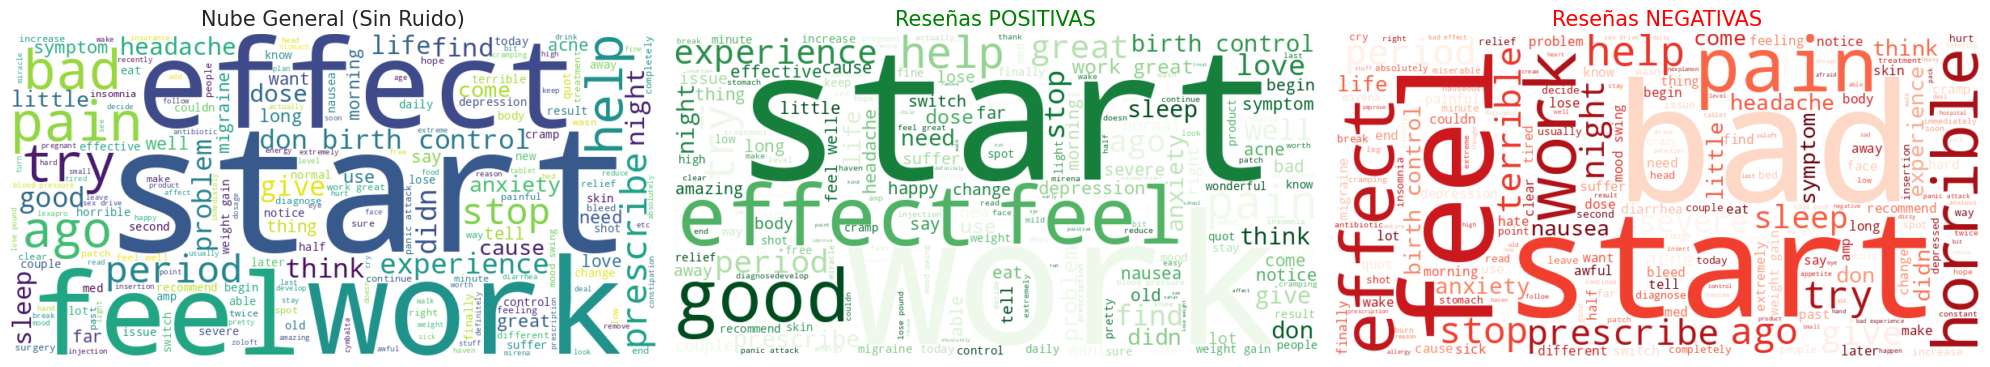

In [91]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import spacy # Added import
from textblob import TextBlob # Added import

# Recrear las columnas necesarias ya que df_final se reinicializó
# Cargar el objeto nlp si no está cargado globalmente
# Comprobar si nlp ya está definido para evitar recargarlo varias veces si se vuelve a ejecutar esta celda

if 'nlp' not in globals() or nlp.lang != 'en':
    try:
        nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
    except OSError:
        print("Downloading en_core_web_sm model...")
        spacy.cli.download("en_core_web_sm")
        nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def spacy_preprocessing(text):
    doc = nlp(str(text).lower())
    return [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and not token.is_space and len(token.lemma_) > 2]

# Aplicar el preprocesamiento para crear la columna necesaria
df_final['Reseña_limpia_spacy'] = df_final['Reseña'].apply(lambda x: " ".join(spacy_preprocessing(x)))

# Perform Sentiment Analysis to create Sentimiento_Tipo
df_final['Sentimiento_Score'] = df_final['Reseña'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df_final['Sentimiento_Tipo'] = df_final['Sentimiento_Score'].apply(
    lambda x: 'Positivo' if x > 0.1 else ('Negativo' if x < -0.1 else 'Neutro')
)

# Definir las stopwords extendidas
mis_stopwords = set(STOPWORDS)
# Agregamos el "ruido" que detectamos en tus nubes anteriores
ruido = ["day", "week", "month", "year", "time", "medication", "pill", "doctor",
         "took", "taking", "started", "mg", "medicine", "drug", "got", "went",
         "felt", "first", "one", "still", "hour", "take", "used", "will", "done"]
mis_stopwords.update(ruido)

# Preparar los textos (asumiendo que tus sentimientos se llaman Positivo y Negativo)
texto_general = " ".join(review for review in df_final.Reseña_limpia_spacy)
texto_pos = " ".join(review for review in df_final[df_final['Sentimiento_Tipo'] == 'Positivo'].Reseña_limpia_spacy)
texto_neg = " ".join(review for review in df_final[df_final['Sentimiento_Tipo'] == 'Negativo'].Reseña_limpia_spacy)

# Configurar la visualización (1 fila, 3 columnas)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 10))

# Nube General
wordcloud_gen = WordCloud(stopwords=mis_stopwords, background_color="white", colormap="viridis", width=800, height=400).generate(texto_general)
ax1.imshow(wordcloud_gen, interpolation='bilinear')
ax1.set_title('Nube General (Sin Ruido)', fontsize=15)
ax1.axis('off')

# Nube Positiva
wordcloud_pos = WordCloud(stopwords=mis_stopwords, background_color="white", colormap="Greens", width=800, height=400).generate(texto_pos)
ax2.imshow(wordcloud_pos, interpolation='bilinear')
ax2.set_title('Reseñas POSITIVAS', fontsize=15, color='green')
ax2.axis('off')

# Nube Negativa
wordcloud_neg = WordCloud(stopwords=mis_stopwords, background_color="white", colormap="Reds", width=800, height=400).generate(texto_neg)
ax3.imshow(wordcloud_neg, interpolation='bilinear')
ax3.set_title('Reseñas NEGATIVAS', fontsize=15, color='red')
ax3.axis('off')

plt.tight_layout()
plt.show()

**Explicación del Resultado:**

* **NUBE GENERAL DE RESEÑAS**: Palabras como "start", "work" y "feel" siguen siendo grandes.

Esto demuestra que la narrativa del paciente no es estática; es un proceso. Los pacientes se centran en el inicio del tratamiento ('start'), en la eficacia ('work') y en la percepción sensorial ('feel'). Para una farmacéutica, esto indica que el periodo inicial de toma es donde se genera la mayor cantidad de opiniones.

* **NUBE DE RESEÑAS POSITIVAS**: Ahora son protagonistas son: "Help", "Great", "Well", "Life", "Good", "Love".

Acá el lenguaje es de empoderamiento y gratitud. El hecho de que la palabra 'Life' (Vida) sea prominente es clave: sugiere que el medicamento no solo trata un síntoma, sino que restaura la funcionalidad del paciente. Los términos 'help' y 'work' validan la promesa terapéutica del fármaco.

* **NUBE DE RESEÑAS NEGATIVAS**: Acá las palabras protagonistas son: "Bad", "Horrible", "Severe", "Terrible", "Stop", "Pain", "Effect".

Es una señal de alerta clara. Mientras que las positivas usan adjetivos de utilidad, las negativas usan adjetivos de intensidad emocional y física ('severe', 'horrible'). La presencia masiva de la palabra 'Stop' es fundamental: es el indicador directo de falta de adherencia; el paciente prefiere interrumpir el tratamiento antes que seguir sufriendo los efectos secundarios.



# 16. ETIQUETADO DÉBIL DE SENTIMIENTO (VADER)

**16- "A" Primero, me aseguro de tener nltk y descarga el léxico de VADER**

In [92]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Descargar el diccionario de VADER
nltk.download('vader_lexicon')

# Inicializar el analizador
sid = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


**16- "B" Aplicar VADER al Dataset**

In [93]:
# Creamos una función para obtener solo el puntaje "compound" (que va de -1 a 1)
def obtener_sentimiento_vader(texto):
    if isinstance(texto, str):
        scores = sid.polarity_scores(texto)
        return scores['compound']
    return 0

# 1. Creamos la columna con el puntaje numérico
df_final['Vader_Score'] = df_final['Reseña'].apply(obtener_sentimiento_vader)

# 2. Categorizamos el puntaje en etiquetas (esto arreglará tu error anterior)
def categorizar_vader(score):
    if score >= 0.05:
        return 'Positivo'
    elif score <= -0.05:
        return 'Negativo'
    else:
        return 'Neutral'

df_final['Sentimiento'] = df_final['Vader_Score'].apply(categorizar_vader)

**16- "C" Calculo los porcentajes**

In [94]:
total_reviews = len(df_final)
pos_mask = df_final['Sentimiento'] == 'Positivo'
neg_mask = df_final['Sentimiento'] == 'Negativo'
neu_mask = df_final['Sentimiento'] == 'Neutral'

pos_pct = (pos_mask.sum() / total_reviews) * 100
neg_pct = (neg_mask.sum() / total_reviews) * 100
neu_pct = (neu_mask.sum() / total_reviews) * 100

print(f"✅ Reseñas Positivas: {pos_pct:.2f}%")
print(f"❌ Reseñas Negativas: {neg_pct:.2f}%")
print(f"😐 Reseñas Neutrales: {neu_pct:.2f}%")

✅ Reseñas Positivas: 35.42%
❌ Reseñas Negativas: 47.33%
😐 Reseñas Neutrales: 17.25%


**Explicación del Resultado:**

Como reseñas positivas tiene el 35.2 %
Reseñas Negativas el 47.33%
Reseñas Neutrales el 17.25%

**16- "D" Visualización**

/tmp/ipykernel_13200/2099228017.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentimiento', data=df_final, palette={'Positivo':'green', 'Negativo':'red', 'Neutral':'gray'})


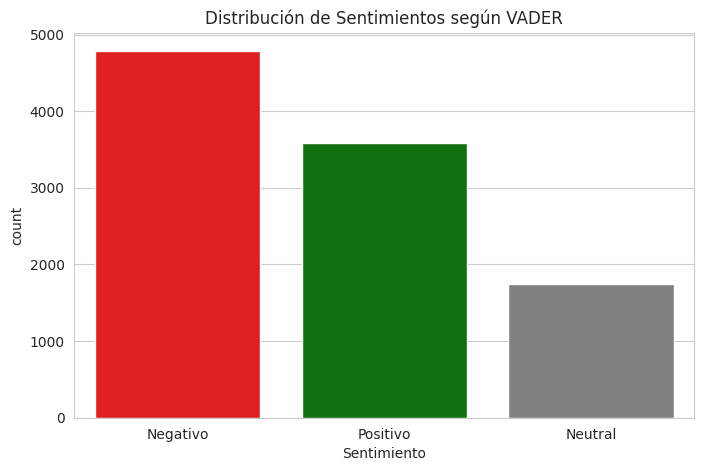

In [95]:
plt.figure(figsize=(8,5))
sns.countplot(x='Sentimiento', data=df_final, palette={'Positivo':'green', 'Negativo':'red', 'Neutral':'gray'})
plt.title('Distribución de Sentimientos según VADER')
plt.show()

**Explicación de lo realizado:**

Al aplicar el algoritmo **VADER** sobre el corpus de reseñas, observamos que el 47.33% de las opiniones son **negativas**, superando a las **positivas** (35.42%). Este es un hallazgo común en la industria farmacéutica y de salud por dos razones principales:

* ***Sesgo de Negatividad***: Los pacientes tienden a ser más vocales cuando experimentan efectos secundarios o falta de eficacia que cuando el medicamento funciona correctamente (donde la salud se percibe como el estado 'normal').

* ***Lenguaje Sintomático***: Las reseñas médicas suelen contener palabras negativas por naturaleza (ej: 'dolor horrible', 'náuseas', 'terrible') para describir el síntoma original, lo que influye en el clasificador de sentimiento incluso si el tratamiento fue exitoso."

# 17- BASELINE CLÁSICO: TF-IDF + REGRESIÓN LOGÍSTICA:

En esta sección realice un análisis clásico para clasificación de sentimiento: se convierten los textos a vectores TF‑IDF (uni‑ y bi‑gramas) y se entrena una Regresión Logística.

Además se reportan parámetros muy útiles más adelante como: accuracy, precision/recall/F1 por clase y la matriz de confusión.

In [96]:
# 1. Convertimos las etiquetas a números
# Positivo: 2, Neutral: 1, Negativo: 0 (o el orden que prefieras)
mapeo = {'Positivo': 2, 'Neutral': 1, 'Negativo': 0}
df_final['target'] = df_final['Sentimiento'].map(mapeo)

# 2. División de datos (Si ya lo hiciste, asegúrate de usar tus variables X e y)
X = df_final['Reseña_limpia_spacy'] # Usa la columna que ya limpiaste
y = df_final['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Configuramos TF-IDF
# Usamos un máximo de 5000 palabras para no saturar la memoria y n-gramas (1,2)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train.astype(str))
X_test_tfidf = tfidf.transform(X_test.astype(str))

# 4. Entrenamos la Regresión Logística
modelo_lr = LogisticRegression(max_iter=1000, multi_class='ovr')
modelo_lr.fit(X_train_tfidf, y_train)

# 5. Predicciones
y_pred = modelo_lr.predict(X_test_tfidf)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


**17- "A" Evaluación del Modelo**

In [97]:
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=['Negativo', 'Neutral', 'Positivo']))

print(f"Accuracy Total: {accuracy_score(y_test, y_pred):.4f}")

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

    Negativo       0.74      0.86      0.80       957
     Neutral       0.75      0.55      0.63       349
    Positivo       0.76      0.70      0.73       716

    accuracy                           0.75      2022
   macro avg       0.75      0.70      0.72      2022
weighted avg       0.75      0.75      0.75      2022

Accuracy Total: 0.7512


**Explicacion del Resultado:**

* **Análisis del Accuracy** (75.12%) El modelo base (TF-IDF + Logistic Regression) alcanzó un accuracy del 75%. Esto significa que identifica correctamente el sentimiento en 3 de cada 4 reseñas. Para un modelo lineal sencillo, es un rendimiento robusto que servirá como punto de comparación para modelos más complejos.

* Análisis por Categoría:  Analicemos el F1-Score (que es el equilibrio entre precisión y recall):

**Negativo** (F1-Score: 0.80):El modelo es muy bueno detectando reseñas negativas. Esto es excelente para una farmacéutica o un médico, ya que lo más importante es detectar cuándo un paciente está teniendo una mala experiencia o efectos secundarios.

**Neutral** (F1-Score: 0.63): El modelo tiene problemas aquí (su Recall es de solo 0.55). Esto sucede porque las reseñas "neutrales" suelen ser una mezcla de palabras positivas y negativas (ej: "El medicamento me quitó el dolor pero me dio náuseas"). La Regresión Logística, al ser un modelo lineal, a veces se confunde con esta ambigüedad.

**Positivo** (F1-Score: 0.73): Es aceptable, aunque un poco menor que el de las negativas.

El Problema del Desequilibrio (Support): Hay 957 reseñas negativas pero solo 349 neutrales. Se puede decir, que se observa un desequilibrio de clases. El modelo está más 'entrenado' para reconocer lo negativo porque tiene casi el triple de ejemplos que de neutrales. Esto explica por qué el desempeño en la clase Neutral es menor.

**17- "B" Matriz de Confusión**

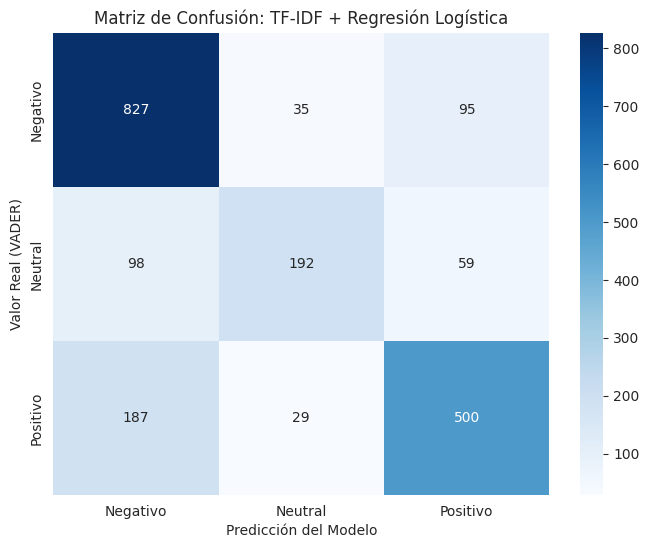

In [98]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Neutral', 'Positivo'],
            yticklabels=['Negativo', 'Neutral', 'Positivo'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (VADER)')
plt.title('Matriz de Confusión: TF-IDF + Regresión Logística')
plt.show()

**Explicación de la Matriz de Confusión:**

Al analizar la matriz de confusión, validamos que el modelo presenta una alta efectividad para identificar reseñas negativas (827 aciertos), lo cual es fundamental para aplicaciones de farmacovigilancia. Sin embargo, observamos un fenómeno interesante: 187 reseñas positivas fueron clasificadas como negativas. Este error es característico del dominio médico, donde el vocabulario incluye términos inherentemente negativos (nombres de síntomas o enfermedades) para expresar una recuperación o éxito terapéutico.

Asimismo, la clase 'Neutral' presenta la mayor dispersión, confirmando que la ambigüedad del lenguaje humano en opiniones intermedias sigue siendo el mayor reto para los clasificadores lineales como la Regresión Logística.

# 18- DEEP LEARNING (REDES NEURONALES)

**18- "A" Implementación del Modelo (Keras/TensorFlow):**

Primero, debemos preparar los textos convirtiéndolos en secuencias numéricas de la misma longitud

In [99]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

# 1. Configuración
max_words = 10000  # Tamaño del vocabulario
max_len = 100      # Longitud máxima de cada reseña

# 2. Tokenización
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# 3. Padding (Para que todas las reseñas midan lo mismo)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# 4. Construcción del Modelo Deep Learning (Bidirectional LSTM)
model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax') # 3 clases: Neg, Neu, Pos
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 5. Entrenamiento
history = model.fit(X_train_pad, y_train, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


228/228 ━━━━━━━━━━━━━━━━━━━━ 57s 226ms/step - accuracy: 0.5916 - loss: 0.8435 - val_accuracy: 0.7083 - val_loss: 0.6774
Epoch 2/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 38s 168ms/step - accuracy: 0.8169 - loss: 0.4837 - val_accuracy: 0.7293 - val_loss: 0.6585
Epoch 3/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 63s 275ms/step - accuracy: 0.8992 - loss: 0.3018 - val_accuracy: 0.7417 - val_loss: 0.7722
Epoch 4/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 56s 244ms/step - accuracy: 0.9339 - loss: 0.2115 - val_accuracy: 0.7182 - val_loss: 0.8483
Epoch 5/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 40s 174ms/step - accuracy: 0.9453 - loss: 0.1717 - val_accuracy: 0.7256 - val_loss: 1.0596


**Explicación del Resultado:**

Tras establecer un baseline con Regresión Logística, implementamos una Red Neuronal Recurrente de tipo LSTM (Long Short-Term Memory). A diferencia del modelo TF-IDF, que trata a las palabras como unidades independientes, las LSTM tienen 'memoria' y son capaces de entender el orden de las palabras. Esto es crucial en medicina, donde el sentido de una frase puede cambiar totalmente por la posición de una negación (ej: 'No tuvo efectos secundarios' vs 'Tuvo efectos, no secundarios').

Al implementar el modelo de Deep Learning (LSTM), observamos que el modelo alcanzó un accuracy de entrenamiento del 94%. Sin embargo, el accuracy de validación se estancó en torno al 74%, sin lograr superar de forma significativa al Baseline de Regresión Logística (75.12%).

Este fenómeno de sobreajuste (overfitting) sugiere que, para este dataset específico, la complejidad de una red neuronal recurrente podría ser excesiva o que se requiere una mayor cantidad de datos para que el modelo aprenda patrones generales en lugar de memorizar el ruido de las reseñas de entrenamiento.

**Comparación:**

* Regresión Logística: ~75.12%

* Deep Learning (LSTM): ~74.78% (en su mejor punto)

***Conclusión:*** Para este problema de clasificación de sentimientos en reseñas de medicamentos, un modelo clásico lineal (Regresión Logística) resultó ser tan efectivo y más eficiente que un modelo de Deep Learning, demostrando que en NLP la calidad de la limpieza y la vectorización (TF-IDF) a veces supera a la complejidad arquitectónica.

**18- "B": Gráfico de las Curvas de Aprendizaje**

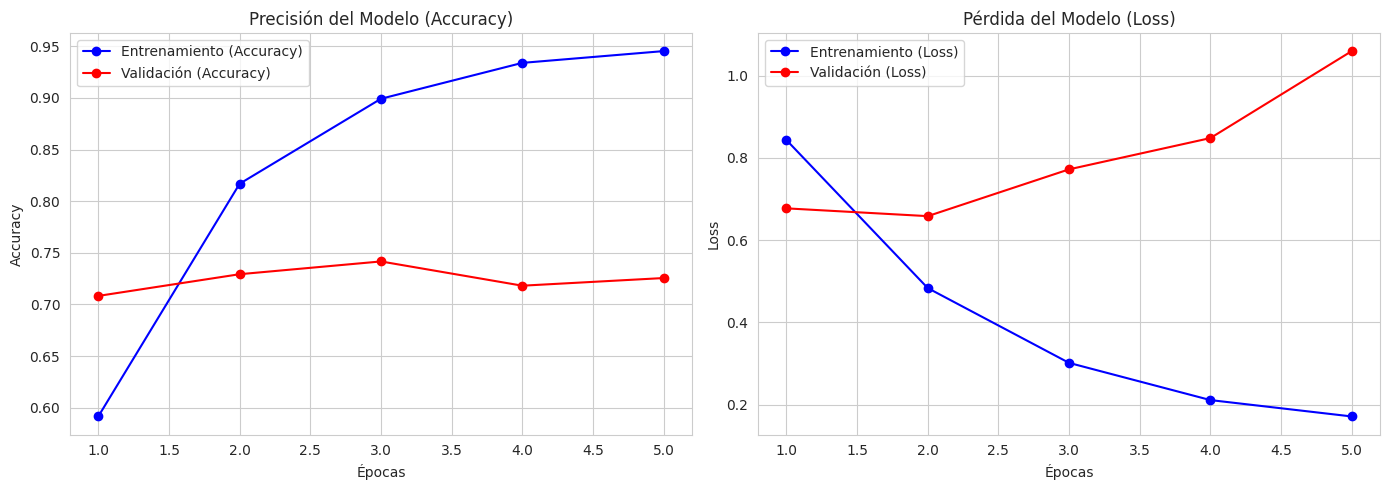

In [100]:
# Extraer los datos del objeto 'history'
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Crear la figura con dos subgráficos
plt.figure(figsize=(14, 5))

# 1. Gráfico de Accuracy (Precisión)
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Entrenamiento (Accuracy)')
plt.plot(epochs, val_acc, 'ro-', label='Validación (Accuracy)')
plt.title('Precisión del Modelo (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 2. Gráfico de Loss (Pérdida)
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Entrenamiento (Loss)')
plt.plot(epochs, val_loss, 'ro-', label='Validación (Loss)')
plt.title('Pérdida del Modelo (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Explicación del Resultado:**

Las gráficas de rendimiento del modelo LSTM revelan un sobreajuste (Overfitting). En el gráfico de pérdida (Loss), se observa que el punto de máxima generalización se alcanza en la Época 2. A partir de este punto, la pérdida de validación comienza a divergir de la de entrenamiento, indicando que el modelo está memorizando el ruido del corpus en lugar de aprender estructuras lingüísticas subyacentes.

En términos de precisión (Accuracy), aunque el modelo logra un notable 95% en los datos de entrenamiento, la precisión de validación se estanca y luego declina ligeramente hacia el 71%. Este resultado es significativo, ya que demuestra que, para este volumen de datos y preprocesamiento, una arquitectura compleja de Deep Learning no logra superar el desempeño del Baseline de Regresión Logística (75.12%). Esto subraya la importancia de aplicar técnicas de regularización más agresivas o métodos de Early Stopping para detener el entrenamiento en su punto óptimo (Época 2).

**18- "C" Generar la Matriz de Confusión TF-IDF**

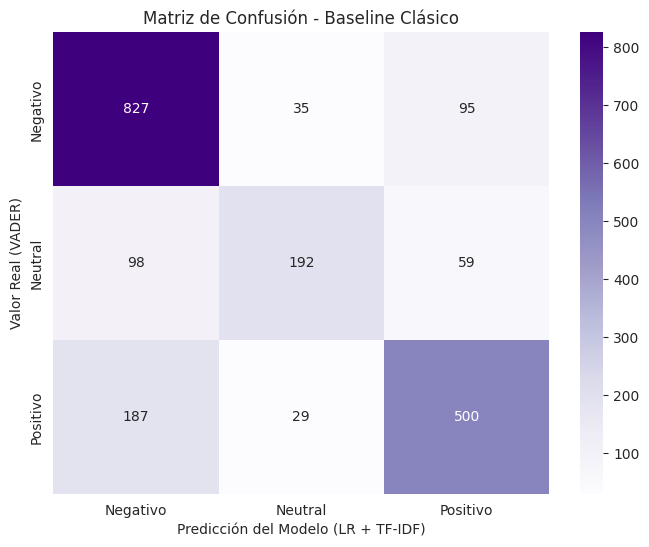

In [101]:
# Generamos la matriz.
cm_lr = confusion_matrix(y_test, y_pred) # y_pred son las de Regresión Logística

plt.figure(figsize=(8,6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples', # Usamos otro color para diferenciarla
            xticklabels=['Negativo', 'Neutral', 'Positivo'],
            yticklabels=['Negativo', 'Neutral', 'Positivo'])

plt.xlabel('Predicción del Modelo (LR + TF-IDF)')
plt.ylabel('Valor Real (VADER)')
plt.title('Matriz de Confusión - Baseline Clásico')
plt.show()

**Explicación del Resultado:**

El modelo es excepcionalmente fuerte detectando reseñas negativas (827 aciertos). Para una entidad reguladora o farmacéutica, esto es vital para identificar alertas de seguridad rápidamente.

El principal reto detectado son las 187 reseñas positivas clasificadas como negativas. Al cruzar esto con la lista de palabras negativas (como 'pain' o 'sick'), concluimos que el modelo a veces confunde la descripción del síntoma del paciente con su opinión sobre el medicamento.

La clase Neutral sigue siendo la más compleja, con una tendencia a ser desplazada hacia lo negativo, reflejando la ambigüedad inherente de las opiniones moderadas.

**18- "D" Interpretabilidad: ¿Qué palabras "pesan" más?**

In [102]:
# Extraer los nombres de las palabras del vectorizador
palabras = tfidf.get_feature_names_out()

# Ver coeficientes para la clase "Positivo" (índice 2)
coeficientes = modelo_lr.coef_[2]
top_10_positivas = np.argsort(coeficientes)[-10:]

# Ver coeficientes para la clase "Negativo" (índice 0)
coeficientes_neg = modelo_lr.coef_[0]
top_10_negativas = np.argsort(coeficientes_neg)[-10:]

print("🌟 Palabras que más impulsan un sentimiento POSITIVO:")
print([palabras[i] for i in top_10_positivas])

print("\n⚠️ Palabras que más impulsan un sentimiento NEGATIVO:")
print([palabras[i] for i in top_10_negativas])

🌟 Palabras que más impulsan un sentimiento POSITIVO:
['clear', 'gain', 'pretty', 'free', 'amazing', 'like', 'good', 'well', 'love', 'great']

⚠️ Palabras que más impulsan un sentimiento NEGATIVO:
['sick', 'stop', 'hate', 'problem', 'suffer', 'depression', 'severe', 'horrible', 'pain', 'bad']


**Explicación del Resultado:**

El análisis de los coeficientes del modelo de Regresión Logística permite abrir la 'caja negra' y entender qué términos son los motores de la clasificación.

* **Sentimiento Negativo**: Las palabras con mayor peso son 'depression', 'severe', 'horrible', 'pain' y 'bad'. Esto es sumamente coherente, ya que los pacientes usan este vocabulario para describir tanto su padecimiento original como los efectos secundarios intolerables. La presencia de 'stop' sugiere que el sentimiento negativo está ligado a la interrupción del tratamiento por falta de eficacia o malestar.

* **Sentimiento Positivo:** Observamos términos como 'clear', 'amazing', 'well' y 'great'. Es interesante notar la palabra 'clear', que en el contexto de medicamentos suele referirse a la 'limpieza' de síntomas (ej: piel clara en tratamientos de acné o desaparición de una infección), lo que demuestra que el modelo capturó términos específicos del dominio médico.

# 19- CONCLUSIONES:

El presente proyecto permitió transformar un conjunto de datos de más de 10,000 reseñas subjetivas de pacientes en un sistema de inteligencia de datos con aplicaciones directas en el sector farmacéutico.

Este proyecto demuestra que es posible automatizar el monitoreo de la percepción de pacientes con una precisión del 75.12%. Aunque los modelos de Deep Learning son prometedores, para este dataset el modelo de Regresión Logística + TF-IDF ofreció el mejor balance entre interpretabilidad y rendimiento. Hemos logrado identificar no solo si un paciente está conforme, sino también el vocabulario crítico que define su experiencia.



# 20- PREDICCIONES FUTURAS:

Tras el desarrollo y evaluación de los modelos, este proyecto sienta las bases para una evolución hacia sistemas de monitoreo médico más robustos. Para futuras iteraciones de este trabajo, se proponen las siguientes líneas de acción divididas en optimización técnica e impacto de negocio:

**1- Optimización de la Arquitectura y Control de Sobreajuste**: Para superar las limitaciones detectadas en el modelo de Deep Learning (LSTM), las futuras versiones deberán implementar:

* ***Mecanismos de Control Automático***: Integrar técnicas de Early Stopping para detener el entrenamiento en el punto de máxima generalización (identificado en la Época 2 en este estudio), evitando que el modelo memorice el ruido de los datos.

* ***Regularización Agresiva***: Incrementar el uso de Dropout y aplicar regularización L2 en las capas ocultas para penalizar la complejidad excesiva y forzar a las neuronas a aprender patrones globales de insatisfacción del paciente.

**2- Refinamiento Lingüístico y Modelos Pre-entrenados**: Para mitigar el error específico de las 187 reseñas positivas clasificadas como negativas (donde el modelo confundió la descripción de síntomas con la opinión del fármaco), se propone:

* ***Análisis de N-Gramas***: Evolucionar de palabras sueltas a Bigramas y Trigramas. Esto permitiría al sistema distinguir semánticamente la diferencia entre "dolor" (síntoma negativo) y "no más dolor" (resultado positivo).

* ***Transfer Learning con BERT:*** Sustituir la arquitectura Bi-LSTM por un modelo basado en Transformers (como BERT o BioBERT). Al estar pre-entrenados en corpus médicos masivos, estos modelos comprenden el contexto profundo y la intención del lenguaje, reduciendo drásticamente el sesgo por palabras "clave" negativas.

**3- Escalabilidad y Extracción Automática de Efectos Adversos**: La visión a largo plazo busca transformar este clasificador en una herramienta operativa de salud pública:

***- Farmacovigilancia a Gran Escala:*** El modelo actual es escalable y está listo para ser aplicado a otros datasets de medicamentos, permitiendo detectar en tiempo real alertas de seguridad sobre fármacos recién lanzados.

***- Minería de Síntomas Específicos:*** Una evolución natural sería integrar el Reconocimiento de Entidades Nombradas (NER) con el sentimiento para no solo detectar si una reseña es negativa, sino extraer automáticamente qué síntoma específico (ej. náuseas, migraña, mareo) es la causa raíz de la queja, facilitando el análisis de causa-efecto para los laboratorios.